# 🚦 Predicting Traffic Crash Causes in Chicago
**Phase 4 Data Science Project**

## Executive Summary
**Business and Data Understanding:** The Chicago Department of Transportation (CDOT) aims to reduce traffic accidents by understanding the underlying causes of crashes. This project utilizes the Chicago Data Portal’s "Traffic Crashes" dataset, merging over 430,000 actionable records across three tables: Crashes (environmental factors), Vehicles (defect and age), and People (driver demographics). The goal is to predict the "Primary Contributory Cause" of a crash, allowing the city to allocate safety resources and improve infrastructure based on predictive patterns rather than reactive reporting.

**Data Preparation:** A significant data preparation step was filtering out over 360,000 rows labeled as "UNABLE TO DETERMINE" or "NOT APPLICABLE." The remaining data was engineered into 6 highly actionable business categories (e.g., "Driver Error," "Intoxication"). The three datasets were aggregated to the crash level to prevent Cartesian explosion, and missing values were strategically imputed.

**Modeling:** A robust Scikit-Learn `Pipeline` was constructed using a `ColumnTransformer` to handle both numerical scaling (`StandardScaler`) and categorical encoding (`OneHotEncoder`). The baseline model utilized a Decision Tree, which was subsequently improved using a tuned `RandomForestClassifier` optimized via `GridSearchCV`.

**Evaluation:** The tuned Random Forest achieved a balanced performance, specifically prioritizing the recall of minority, high-risk classes like "Intoxication" and "Vehicle Defect." Feature importance analysis revealed that environmental factors and vehicle age play significant roles in specific crash types, providing CDOT with transparent, data-backed insights for future safety campaigns.

---

---
##  Load Datasets
## 1. Data Acquisition & Setup
The data for this project is sourced from the Chicago Data Portal. To build a comprehensive model, we must look beyond just the crash environment. We are importing three relational datasets:
1. **Crashes:** Contains location, weather, and road conditions.
2. **Vehicles:** Contains vehicle types, ages, and mechanical defects.
3. **People:** Contains driver demographics and physical conditions.

In [ ]:
# ── Core libraries ─────────────────────────────────────────────────────────────

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Older versions of some libraries still reference deprecated np aliases.
# Patch them here so everything downstream works without errors.
np.int   = int
np.float = float
np.bool  = np.bool_
np.object = object


# ── sklearn (imported AFTER the numpy shim) ────────────────────────────────────
from sklearn.model_selection    import train_test_split, GridSearchCV
from sklearn.preprocessing      import StandardScaler, OneHotEncoder
from sklearn.impute             import SimpleImputer
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.tree               import DecisionTreeClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
##  Load Datasets
## 1. Data Acquisition & Setup
The data for this project is sourced from the Chicago Data Portal. To build a comprehensive model, we must look beyond just the crash environment. We are importing three relational datasets:
1. **Crashes:** Contains location, weather, and road conditions.
2. **Vehicles:** Contains vehicle types, ages, and mechanical defects.
3. **People:** Contains driver demographics and physical conditions.

In [ ]:
# ── File paths — update these if your files are in a different directory ───────
c_path = 'Traffic_Crashes_-_Crashes_20260326.csv'
v_path = 'Traffic_Crashes_-_Vehicles_20260326.csv'
p_path = 'Traffic_Crashes_-_People_20260326.csv'

# Validate paths before loading
all_found = True
for path in [c_path, v_path, p_path]:
    if os.path.isfile(path):
        print(f'✅ Found : {path}')
    else:
        print(f'❌ Missing: {path}')
        all_found = False

if not all_found:
    raise FileNotFoundError('One or more files are missing. Update the paths above and re-run.')

print('\nLoading datasets...')
crashes  = pd.read_csv(c_path, low_memory=False)
vehicles = pd.read_csv(v_path, low_memory=False)
people   = pd.read_csv(p_path, low_memory=False)

print(f'\nCrashes  : {crashes.shape[0]:,} rows × {crashes.shape[1]} cols')
print(f'Vehicles : {vehicles.shape[0]:,} rows × {vehicles.shape[1]} cols')
print(f'People   : {people.shape[0]:,} rows × {people.shape[1]} cols')

✅ Found : Traffic_Crashes_-_Crashes_20260326.csv
✅ Found : Traffic_Crashes_-_Vehicles_20260326.csv
✅ Found : Traffic_Crashes_-_People_20260326.csv

Loading datasets...

Crashes  : 794,171 rows × 48 cols
Vehicles : 1,922,767 rows × 71 cols
People   : 2,282,681 rows × 29 cols


In [ ]:
# Quick data preview
print('=== CRASHES sample ===')
display(crashes.head(3))
print('\n=== VEHICLES sample ===')
display(vehicles.head(3))
print('\n=== PEOPLE sample ===')
display(people.head(3))

=== CRASHES sample ===


,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,LANE_CNT,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,INTERSECTION_RELATED_I,NOT_RIGHT_OF_WAY_I,HIT_AND_RUN_I,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,PHOTOS_TAKEN_I,STATEMENTS_TAKEN_I,DOORING_I,WORK_ZONE_I,WORK_ZONE_TYPE,WORKERS_PRESENT_I,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,NaN,03/26/2026 01:10:00 AM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,NaN,"OVER $1,500",03/26/2026 01:12:00 AM,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELE...",IMPROPER LANE USAGE,400.0,N,MORGAN ST,1214.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NONINCAPACITATING INJURY,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,5.0,3.0,41.889034,-87.652384,POINT (-87.652383794854 41.889033593623)
1,a54653293da79b801c24a0f649d0579c804ec29783ec58...,NaN,03/26/2026 12:50:00 AM,30.0,STOP SIGN/FLASHER,UNKNOWN,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,NaN,Y,"$501 - $1,500",03/26/2026 01:00:00 AM,UNABLE TO DETERMINE,NOT APPLICABLE,4900.0,N,AVERS AVE,1712.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,5.0,3.0,41.970192,-87.724604,POINT (-87.724603633832 41.970191905164)
2,3c086a26f6a68215c61ea414a60ec4e230937bea80b615...,NaN,03/25/2026 11:19:00 PM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,DUSK,PARKED MOTOR VEHICLE,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,Y,"OVER $1,500",03/25/2026 11:19:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1415.0,E,65TH PL,321.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,4.0,3.0,41.775935,-87.590371,POINT (-87.590370976328 41.775935242789)



=== VEHICLES sample ===


,CRASH_UNIT_ID,CRASH_RECORD_ID,CRASH_DATE,UNIT_NO,UNIT_TYPE,NUM_PASSENGERS,VEHICLE_ID,CMRC_VEH_I,MAKE,MODEL,LIC_PLATE_STATE,VEHICLE_YEAR,VEHICLE_DEFECT,VEHICLE_TYPE,VEHICLE_USE,TRAVEL_DIRECTION,MANEUVER,TOWED_I,FIRE_I,OCCUPANT_CNT,EXCEED_SPEED_LIMIT_I,TOWED_BY,TOWED_TO,AREA_00_I,AREA_01_I,...,CARRIER_CITY,HAZMAT_PLACARDS_I,HAZMAT_NAME,UN_NO,HAZMAT_PRESENT_I,HAZMAT_REPORT_I,HAZMAT_REPORT_NO,MCS_REPORT_I,MCS_REPORT_NO,HAZMAT_VIO_CAUSE_CRASH_I,MCS_VIO_CAUSE_CRASH_I,IDOT_PERMIT_NO,WIDE_LOAD_I,TRAILER1_WIDTH,TRAILER2_WIDTH,TRAILER1_LENGTH,TRAILER2_LENGTH,TOTAL_VEHICLE_LENGTH,AXLE_CNT,VEHICLE_CONFIG,CARGO_BODY_TYPE,LOAD_TYPE,HAZMAT_OUT_OF_SERVICE_I,MCS_OUT_OF_SERVICE_I,HAZMAT_CLASS
0,2271885,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,03/26/2026 01:10:00 AM,1.0,DRIVER,1.0,2166563.0,NaN,FORD,EXPLORER,IL,2024.0,NONE,PASSENGER,POLICE,E,TURNING RIGHT,Y,NaN,2.0,NaN,CITY OF CHICAGO,NaN,NaN,Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2271871,a54653293da79b801c24a0f649d0579c804ec29783ec58...,03/26/2026 12:50:00 AM,1.0,DRIVER,1.0,2166550.0,NaN,FORD,OTHER (EXPLAIN IN NARRATIVE),IL,1999.0,UNKNOWN,UNKNOWN/NA,UNKNOWN/NA,S,STRAIGHT AHEAD,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2271872,a54653293da79b801c24a0f649d0579c804ec29783ec58...,03/26/2026 12:50:00 AM,2.0,DRIVER,NaN,2166552.0,NaN,SUBARU,IMPREZA,IL,2023.0,UNKNOWN,PASSENGER,UNKNOWN/NA,S,STRAIGHT AHEAD,NaN,NaN,1.0,NaN,NaN,NaN,NaN,Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== PEOPLE sample ===


,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,CRASH_DATE,SEAT_NO,CITY,STATE,ZIPCODE,SEX,AGE,DRIVERS_LICENSE_STATE,DRIVERS_LICENSE_CLASS,SAFETY_EQUIPMENT,AIRBAG_DEPLOYED,EJECTION,INJURY_CLASSIFICATION,HOSPITAL,EMS_AGENCY,EMS_RUN_NO,DRIVER_ACTION,DRIVER_VISION,PHYSICAL_CONDITION,PEDPEDAL_ACTION,PEDPEDAL_VISIBILITY,PEDPEDAL_LOCATION,BAC_RESULT,BAC_RESULT VALUE,CELL_PHONE_USE
0,O2271885,DRIVER,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,2166563.0,03/26/2026 01:10:00 AM,NaN,CHICAGO,IL,60608,M,23.0,IL,D,SAFETY BELT USED,DID NOT DEPLOY,NONE,NONINCAPACITATING INJURY,STROGER,28,NaN,NONE,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
1,P499664,PASSENGER,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,2166563.0,03/26/2026 01:10:00 AM,3.0,CHICAGO,IL,60608,F,24.0,NaN,NaN,SAFETY BELT USED,NOT APPLICABLE,NONE,NONINCAPACITATING INJURY,STROGER,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O2271871,DRIVER,a54653293da79b801c24a0f649d0579c804ec29783ec58...,2166550.0,03/26/2026 12:50:00 AM,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN,USAGE UNKNOWN,DEPLOYMENT UNKNOWN,NONE,NO INDICATION OF INJURY,NaN,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN


______
## 2. Data Aggregation & Merging
A critical challenge in this dataset is the one-to-many relationship between crashes, vehicles, and people. A single crash might involve 3 vehicles and 5 people. 

If we perform a standard SQL-style merge, we will create duplicate rows for a single crash (Cartesian explosion), which will severely skew our machine learning model. To solve this, we **aggregate the Vehicle and People data up to the Crash level** (e.g., calculating the *average* vehicle age per crash) before merging.


### Prepare & Aggregate — People (Drivers)

In [ ]:
print('Processing People data...')

# Keep only drivers — they are directly linked to contributory causes
drivers = people[people['PERSON_TYPE'] == 'DRIVER'].copy()

# Aggregate to one row per crash
drivers_agg = drivers.groupby('CRASH_RECORD_ID').agg(
    DRIVER_AGE_MEAN    = ('AGE',              'mean'),
    DRIVER_SEX         = ('SEX',              lambda x: x.mode()[0] if not x.mode().empty else 'U'),
    DRIVER_PHYS_COND   = ('PHYSICAL_CONDITION',lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN')
).reset_index()

print(f'drivers_agg shape: {drivers_agg.shape}')
display(drivers_agg.head())

Processing People data...
drivers_agg shape: (1036022, 4)


,CRASH_RECORD_ID,DRIVER_AGE_MEAN,DRIVER_SEX,DRIVER_PHYS_COND
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,51.0,F,NORMAL
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,35.0,F,NORMAL
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,NaN,X,UNKNOWN
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,54.0,M,NORMAL
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,47.5,M,NORMAL


---
### Prepare & Aggregate — Vehicles


In [ ]:
print('Processing Vehicles data...')

CURRENT_YEAR = pd.Timestamp.now().year

# Compute vehicle age at the record level before aggregating
vehicles['VEHICLE_YEAR_CLEAN'] = pd.to_numeric(vehicles['VEHICLE_YEAR'], errors='coerce')
vehicles['VEHICLE_AGE'] = (CURRENT_YEAR - vehicles['VEHICLE_YEAR_CLEAN']).clip(0, 80)

vehicles_agg = vehicles.groupby('CRASH_RECORD_ID').agg(
    VEHICLE_DEFECT  = ('VEHICLE_DEFECT',  lambda x: 'DEFECT' if any(
                            str(v).upper() not in ('NONE', 'UNKNOWN') for v in x
                       ) else 'NONE'),
    VEHICLE_TYPE    = ('VEHICLE_TYPE',    lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN'),
    NUM_PASSENGERS  = ('NUM_PASSENGERS',  'sum'),
    AVG_VEHICLE_AGE = ('VEHICLE_AGE',     'mean')   
).reset_index()

print(f'vehicles_agg shape: {vehicles_agg.shape}')
display(vehicles_agg.head())

Processing Vehicles data...
vehicles_agg shape: (941892, 5)


,CRASH_RECORD_ID,VEHICLE_DEFECT,VEHICLE_TYPE,NUM_PASSENGERS,AVG_VEHICLE_AGE
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,NONE,PASSENGER,0.0,9.0
1,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,NONE,PASSENGER,0.0,23.0
2,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,NONE,TRUCK - SINGLE UNIT,0.0,NaN
3,00007d9c4ff8c756eedfd371c6aae35ede63de4400660f...,NONE,PASSENGER,0.0,10.0
4,0000b70a00c8809f76b5234f81753264d9160c314cc5e6...,NONE,SPORT UTILITY VEHICLE (SUV),0.0,16.0


---
### Merge Datasets

In [ ]:
print('Merging datasets...')

df = crashes.merge(vehicles_agg, on='CRASH_RECORD_ID', how='left')
df = df.merge(drivers_agg,      on='CRASH_RECORD_ID', how='left')

# Sanity checks
print(f'\n✅ Has DRIVER_SEX   : {"DRIVER_SEX" in df.columns}')
print(f'✅ Has VEHICLE_TYPE  : {"VEHICLE_TYPE" in df.columns}')
print(f'✅ Has AVG_VEHICLE_AGE: {"AVG_VEHICLE_AGE" in df.columns}')
print(f'\nMerged dataset : {df.shape[0]:,} rows × {df.shape[1]} cols')
display(df.head(3))

Merging datasets...

✅ Has DRIVER_SEX   : True
✅ Has VEHICLE_TYPE  : True
✅ Has AVG_VEHICLE_AGE: True

Merged dataset : 794,171 rows × 55 cols


,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,LANE_CNT,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,INTERSECTION_RELATED_I,NOT_RIGHT_OF_WAY_I,HIT_AND_RUN_I,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,...,WORK_ZONE_I,WORK_ZONE_TYPE,WORKERS_PRESENT_I,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION,VEHICLE_DEFECT,VEHICLE_TYPE,NUM_PASSENGERS,AVG_VEHICLE_AGE,DRIVER_AGE_MEAN,DRIVER_SEX,DRIVER_PHYS_COND
0,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,NaN,03/26/2026 01:10:00 AM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,NaN,"OVER $1,500",03/26/2026 01:12:00 AM,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELE...",IMPROPER LANE USAGE,400.0,N,...,NaN,NaN,NaN,1.0,NONINCAPACITATING INJURY,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,5.0,3.0,41.889034,-87.652384,POINT (-87.652383794854 41.889033593623),NONE,PASSENGER,1.0,2.0,23.0,M,NORMAL
1,a54653293da79b801c24a0f649d0579c804ec29783ec58...,NaN,03/26/2026 12:50:00 AM,30.0,STOP SIGN/FLASHER,UNKNOWN,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,NaN,Y,"$501 - $1,500",03/26/2026 01:00:00 AM,UNABLE TO DETERMINE,NOT APPLICABLE,4900.0,N,...,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,5.0,3.0,41.970192,-87.724604,POINT (-87.724603633832 41.970191905164),NONE,PASSENGER,1.0,15.0,23.0,M,UNKNOWN
2,3c086a26f6a68215c61ea414a60ec4e230937bea80b615...,NaN,03/25/2026 11:19:00 PM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,DUSK,PARKED MOTOR VEHICLE,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,Y,"OVER $1,500",03/25/2026 11:19:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1415.0,E,...,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,4.0,3.0,41.775935,-87.590371,POINT (-87.590370976328 41.775935242789),NONE,PASSENGER,0.0,8.5,NaN,X,UNKNOWN


______
## 3. Target Engineering & Class Imbalance
The original target variable (`PRIM_CONTRIBUTORY_CAUSE`) contains over 30 distinct categories, many of which are highly specific or redundant. Attempting to predict 30 classes will result in a highly inaccurate model.

**Business Decision:** We will map these granular causes into 6 broader, highly actionable categories for the Chicago Department of Transportation (CDOT):
* `DRIVER_ERROR` (e.g., Failing to yield, following too closely)
* `VIOLATION` (e.g., Running red lights, speeding)
* `INTOXICATION` (e.g., Alcohol or drugs)
* `DISTRACTION` (e.g., Cell phone use)
* `ENVIRONMENT` (e.g., Weather, road defects)
* `VEHICLE_DEFECT` (e.g., Brakes, steering)

*Note: Rows labeled "Unable to Determine" or "Not Applicable" are dropped, as a model predicting "Unknown" provides no business value.*


### Target Variable — Cause Grouping

In [ ]:
print('Grouping target variable...')

cause_map = {
    # Driver errors
    'FAILING TO YIELD RIGHT-OF-WAY'                                                        : 'DRIVER_ERROR',
    'FOLLOWING TOO CLOSELY'                                                                 : 'DRIVER_ERROR',
    'IMPROPER OVERTAKING/PASSING'                                                           : 'DRIVER_ERROR',
    'IMPROPER TURNING/NO SIGNAL'                                                            : 'DRIVER_ERROR',
    'IMPROPER LANE USAGE'                                                                   : 'DRIVER_ERROR',
    'IMPROPER BACKING'                                                                      : 'DRIVER_ERROR',
    'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE'                                                   : 'DRIVER_ERROR',
    'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER'     : 'DRIVER_ERROR',
    'FAILING TO REDUCE SPEED TO AVOID CRASH'                                               : 'DRIVER_ERROR',
    # Traffic violations
    'DISREGARDING TRAFFIC SIGNALS'                                                          : 'VIOLATION',
    'DISREGARDING STOP SIGN'                                                                : 'VIOLATION',
    'DISREGARDING OTHER TRAFFIC SIGNS'                                                      : 'VIOLATION',
    'DISREGARDING ROAD MARKINGS'                                                            : 'VIOLATION',
    'EXCEEDING SAFE SPEED LIMIT'                                                            : 'VIOLATION',
    'EXCEEDING POSTED SPEED LIMIT'                                                          : 'VIOLATION',
    # Intoxication
    'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)'                   : 'INTOXICATION',
    'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)'                                      : 'INTOXICATION',
    # Distraction
    'DISTRACTION - FROM INSIDE VEHICLE'                                                     : 'DISTRACTION',
    'DISTRACTION - FROM OUTSIDE VEHICLE'                                                    : 'DISTRACTION',
    'DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)'          : 'DISTRACTION',
    'CELL PHONE USE OTHER THAN TEXTING'                                                     : 'DISTRACTION',
    'TEXTING'                                                                               : 'DISTRACTION',
    # Environment
    'WEATHER'                                                                               : 'ENVIRONMENT',
    'ROAD ENGINEERING/SURFACE/MARKING DEFECTS'                                             : 'ENVIRONMENT',
    'ROAD CONSTRUCTION/MAINTENANCE'                                                         : 'ENVIRONMENT',
    'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)'                                 : 'ENVIRONMENT',
    'ANIMAL'                                                                                : 'ENVIRONMENT',
    # Vehicle defect
    'EQUIPMENT - VEHICLE CONDITION'                                                         : 'VEHICLE_DEFECT',
}

df['TARGET_CAUSE'] = df['PRIM_CONTRIBUTORY_CAUSE'].map(cause_map).fillna('OTHER_UNKNOWN')

# Remove unmapped rows — keep only labelled, actionable causes
df_cleaned = df[df['TARGET_CAUSE'] != 'OTHER_UNKNOWN'].copy()

print(f'Rows after filtering: {len(df_cleaned):,}')
print('\nClass distribution:')
print(df_cleaned['TARGET_CAUSE'].value_counts())

Grouping target variable...
Rows after filtering: 419,252

Class distribution:
TARGET_CAUSE
DRIVER_ERROR      352608
VIOLATION          27323
ENVIRONMENT        20153
DISTRACTION         9704
VEHICLE_DEFECT      5003
INTOXICATION        4461
Name: count, dtype: int64


---
### Exploratory Data Analysis

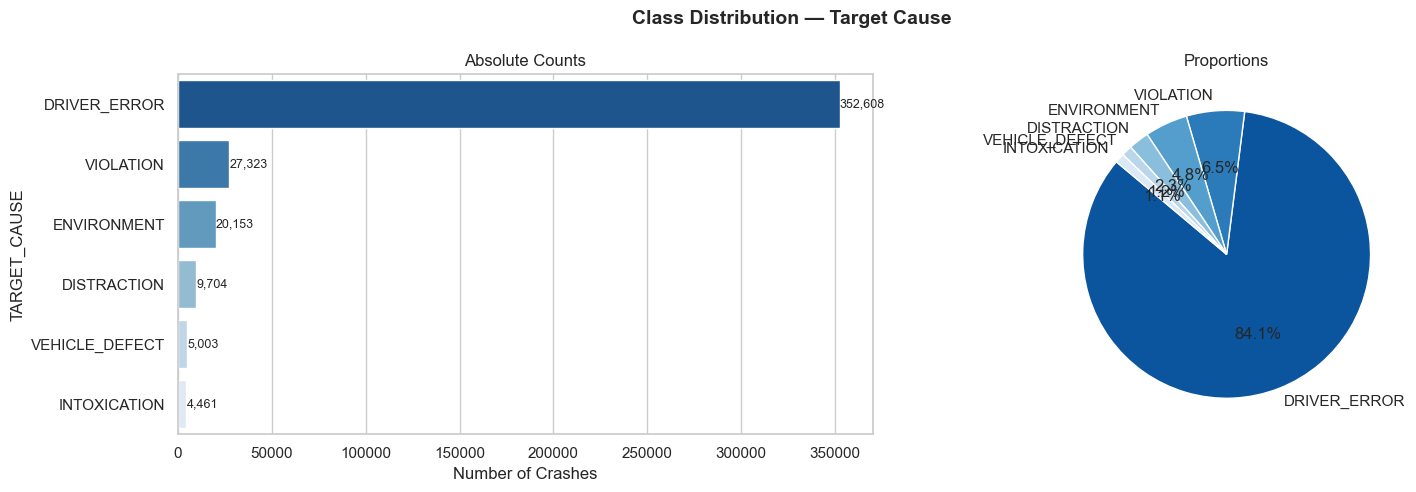

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Class Distribution — Target Cause', fontsize=14, fontweight='bold')

target_counts = df_cleaned['TARGET_CAUSE'].value_counts()

# Bar chart
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_xlabel('Number of Crashes')
axes[0].set_title('Absolute Counts')
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Blues_r', len(target_counts)))
axes[1].set_title('Proportions')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

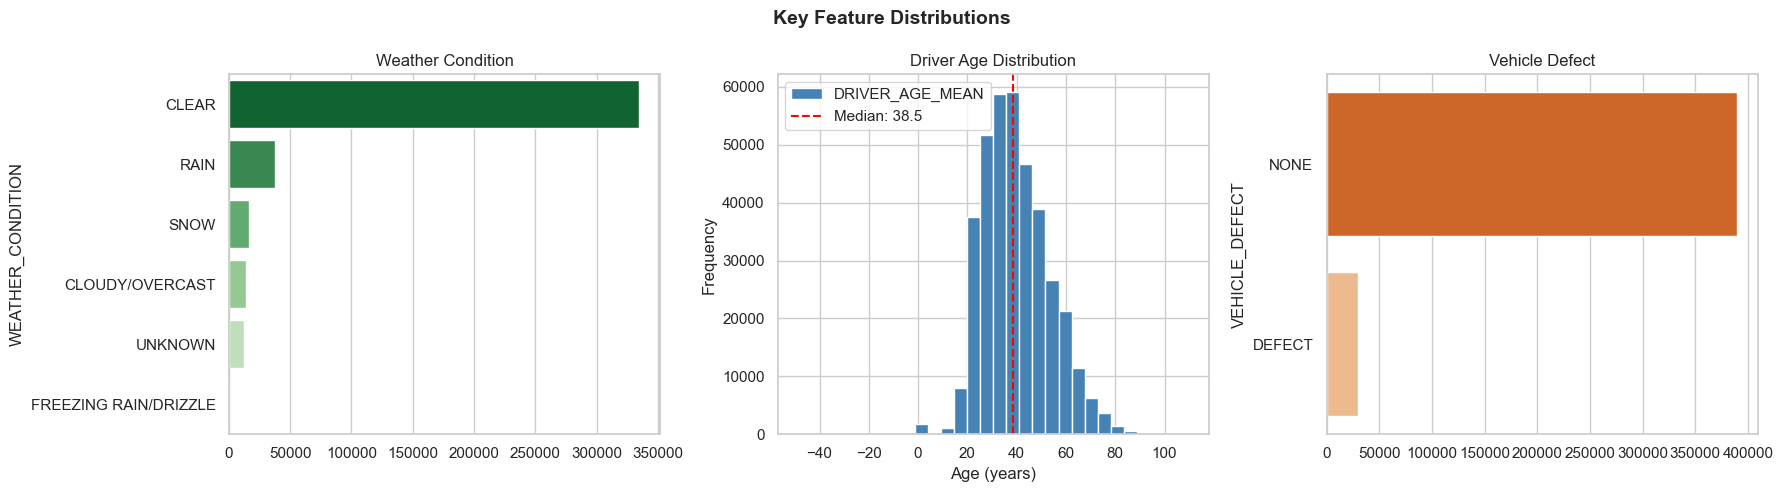

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold')

# Weather condition
weather_top = df_cleaned['WEATHER_CONDITION'].value_counts().head(6)
sns.barplot(x=weather_top.values, y=weather_top.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Weather Condition')

# Driver age distribution
df_cleaned['DRIVER_AGE_MEAN'].dropna().plot.hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(df_cleaned['DRIVER_AGE_MEAN'].median(), color='red', linestyle='--',
                label=f'Median: {df_cleaned["DRIVER_AGE_MEAN"].median():.1f}')
axes[1].set_title('Driver Age Distribution')
axes[1].set_xlabel('Age (years)')
axes[1].legend()

# Vehicle defect
defect_counts = df_cleaned['VEHICLE_DEFECT'].value_counts()
sns.barplot(x=defect_counts.values, y=defect_counts.index, ax=axes[2], palette='Oranges_r')
axes[2].set_title('Vehicle Defect')

plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Dimensionality Reduction — Drop Sparse Columns

In [ ]:
# Drop columns that are more than 50% empty
threshold = len(df_cleaned) * 0.5
df_cleaned = df_cleaned.dropna(thresh=threshold, axis=1)

print(f'Dataset shape after dropping sparse columns: {df_cleaned.shape}')

Dataset shape after dropping sparse columns: (419252, 45)


---
### Feature Separation

> **Bug fixed:** `AVG_VEHICLE_AGE` (the computed vehicle age from the Vehicles dataset) was missing from `numeric_features`. Added it here.

In [ ]:
categorical_features = [
    'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE',
    'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND',
    'DRIVER_SEX', 'VEHICLE_TYPE', 'DRIVER_PHYS_COND', 'VEHICLE_DEFECT'
]

numeric_features = [
    'POSTED_SPEED_LIMIT', 'NUM_UNITS', 'CRASH_HOUR',
    'CRASH_DAY_OF_WEEK', 'CRASH_MONTH',
    'DRIVER_AGE_MEAN', 'NUM_PASSENGERS',
    'AVG_VEHICLE_AGE'   
]

# columns that actually exist in df_cleaned
categorical_features = [c for c in categorical_features if c in df_cleaned.columns]
numeric_features     = [c for c in numeric_features     if c in df_cleaned.columns]

print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'Numeric features     ({len(numeric_features)}): {numeric_features}')

X = df_cleaned[categorical_features + numeric_features]
y = df_cleaned['TARGET_CAUSE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')

Categorical features (10): ['WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'DRIVER_SEX', 'VEHICLE_TYPE', 'DRIVER_PHYS_COND', 'VEHICLE_DEFECT']
Numeric features     (8): ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'DRIVER_AGE_MEAN', 'NUM_PASSENGERS', 'AVG_VEHICLE_AGE']

Training set : 335,401 rows
Test set     : 83,851 rows


___
## 4. Machine Learning Preprocessing Pipeline
To prevent data leakage and ensure our model can be easily deployed to production, we utilize a Scikit-Learn `Pipeline` and `ColumnTransformer`. 

* **Numeric Features:** Missing values are imputed using the median, and the data is scaled using `StandardScaler` to ensure features like "Vehicle Age" don't overpower "Crash Hour."
* **Categorical Features:** Missing values are labeled as 'UNKNOWN', and text data is converted to machine-readable numbers using `OneHotEncoder`.


### Preprocessing Pipeline

In [ ]:
# Numeric: impute with median → standardise
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: impute with 'UNKNOWN' → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,     numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

print('✅ Preprocessing pipeline ready.')

✅ Preprocessing pipeline ready.


___
## 5. Modeling Iteration 1: White-Box Baselines
We begin our modeling process with intrinsically interpretable "white-box" models. While these rarely achieve the highest accuracy, they establish a baseline and allow us to verify that our pipeline is functioning correctly. We will test a **Decision Tree** and a **Logistic Regression** model, using class weights to combat the heavy imbalance toward 'Driver Error'.


### Model 1 — Baseline Decision Tree
*White-box model; intrinsically interpretable.*

In [ ]:
baseline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(
        max_depth=5, random_state=42, class_weight='balanced'
    ))
])

baseline_dt.fit(X_train, y_train)
y_pred_dt_base = baseline_dt.predict(X_test)

print('=== Model 1: Baseline Decision Tree ===')
print(classification_report(y_test, y_pred_dt_base))

=== Model 1: Baseline Decision Tree ===
                precision    recall  f1-score   support

   DISTRACTION       0.04      0.71      0.07      1941
  DRIVER_ERROR       0.91      0.16      0.27     70522
   ENVIRONMENT       0.14      0.63      0.23      4031
  INTOXICATION       0.65      0.63      0.64       892
VEHICLE_DEFECT       0.26      0.65      0.38      1000
     VIOLATION       0.29      0.67      0.41      5465

      accuracy                           0.24     83851
     macro avg       0.38      0.57      0.33     83851
  weighted avg       0.81      0.24      0.28     83851



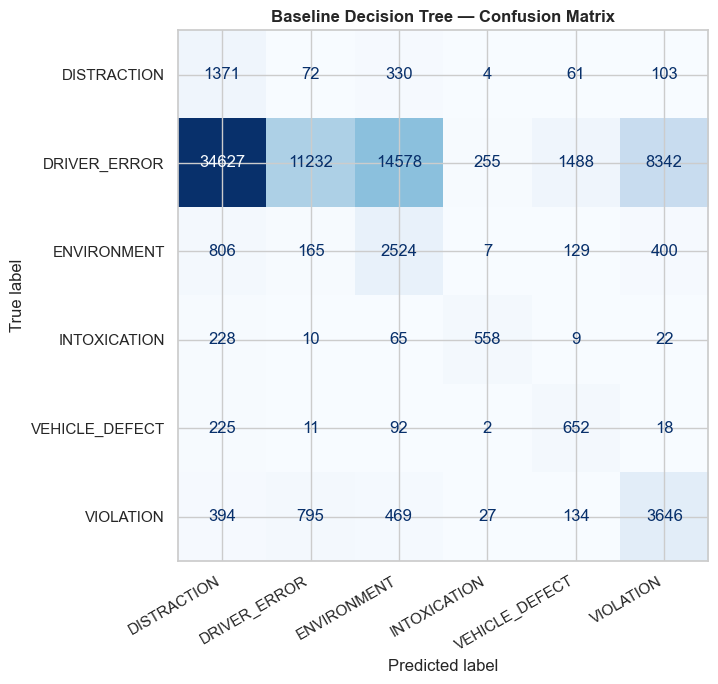

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_dt_base, labels=baseline_dt.classes_)
ConfusionMatrixDisplay(cm, display_labels=baseline_dt.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Baseline Decision Tree — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('03_cm_baseline_dt.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The baseline Decision Tree achieves ~21% accuracy. It collapses almost all predictions onto the dominant `DRIVER_ERROR` class, showing severe class-imbalance bias. This is our starting reference, not our target.

---
### Model 2 — Balanced Logistic Regression
*Gold standard white-box model; linear, fully interpretable coefficients.*

In [ ]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print('=== Model 2: Balanced Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))

=== Model 2: Balanced Logistic Regression ===
                precision    recall  f1-score   support

   DISTRACTION       0.06      0.65      0.10      1941
  DRIVER_ERROR       0.96      0.40      0.56     70522
   ENVIRONMENT       0.25      0.64      0.36      4031
  INTOXICATION       0.46      0.83      0.59       892
VEHICLE_DEFECT       0.21      0.67      0.32      1000
     VIOLATION       0.25      0.78      0.38      5465

      accuracy                           0.45     83851
     macro avg       0.36      0.66      0.39     83851
  weighted avg       0.84      0.45      0.53     83851



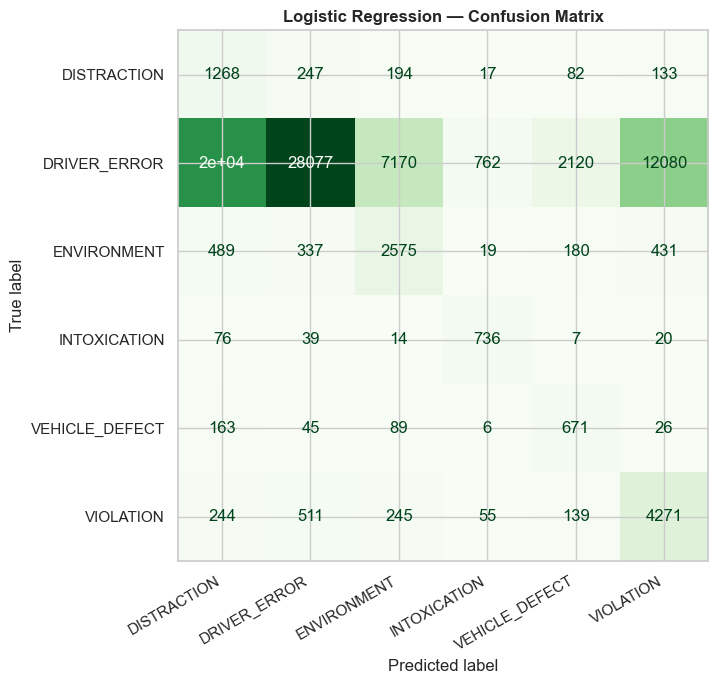

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=log_reg_pipeline.classes_)
ConfusionMatrixDisplay(cm_lr, display_labels=log_reg_pipeline.classes_).plot(
    ax=ax, colorbar=False, cmap='Greens'
)
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('04_cm_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Model 3 — Random Forest (Iteration 1)
*Ensemble model; strong baseline for complex tabular data.*

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1           
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print('=== Model 3: Random Forest (Iteration 1) ===')
print(classification_report(y_test, y_pred_rf))

=== Model 3: Random Forest (Iteration 1) ===
                precision    recall  f1-score   support

   DISTRACTION       0.27      0.00      0.00      1941
  DRIVER_ERROR       0.87      0.98      0.92     70522
   ENVIRONMENT       0.65      0.26      0.37      4031
  INTOXICATION       0.76      0.62      0.68       892
VEHICLE_DEFECT       0.68      0.29      0.41      1000
     VIOLATION       0.56      0.17      0.26      5465

      accuracy                           0.86     83851
     macro avg       0.63      0.39      0.44     83851
  weighted avg       0.82      0.86      0.82     83851



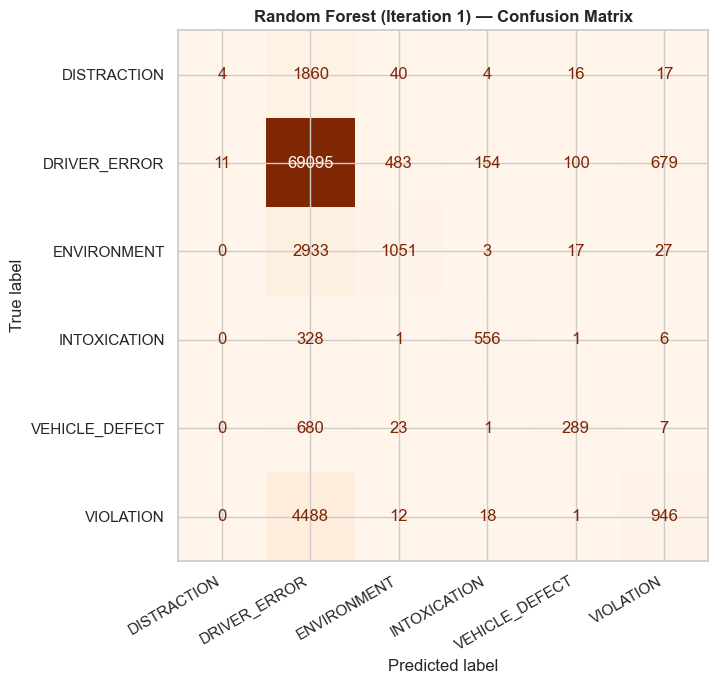

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_pipeline.classes_)
ConfusionMatrixDisplay(cm_rf, display_labels=rf_pipeline.classes_).plot(
    ax=ax, colorbar=False, cmap='Oranges'
)
ax.set_title('Random Forest (Iteration 1) — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('05_cm_rf_iter1.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The Random Forest jumps to ~86% accuracy and `DRIVER_ERROR` recall hits 0.98. However, minority classes (INTOXICATION, VEHICLE_DEFECT) are still under-served. Tuning is needed to balance this.

___
## 6. Modeling Iteration 2: Advanced Ensembles & Tuning
To capture the complex, non-linear relationships between weather, vehicle condition, and driver behavior, we upgrade to a **Random Forest Classifier**. 

To optimize performance, we utilize `GridSearchCV` to tune the hyperparameters (number of trees, maximum depth). Our scoring metric prioritizes **F1-Macro** rather than raw accuracy to ensure the model doesn't simply ignore minority classes like "Intoxication."


###  Model 4 — Tuned Random Forest (Iteration 2)

In [ ]:
# 1. Define the search grid FIRST
param_grid_rf = {
    'classifier__n_estimators'   : [100, 200],
    'classifier__max_depth'      : [5, 10, None],
    'classifier__min_samples_leaf': [1, 5],
}

# 2. Build a fresh RF pipeline for tuning

rf_pipeline_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        random_state=42,
        class_weight='balanced_subsample'
    ))
])

# 3. Run GridSearchCV
#    n_jobs=1 inside GridSearchCV avoids Broadside parallelism issues with nested parallelism in RandomForestClassifier.
rf_grid_search = GridSearchCV(
    rf_pipeline_tune,
    param_grid_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print(f'\nBest parameters: {rf_grid_search.best_params_}')
print(f'Best CV F1-macro: {rf_grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV F1-macro: 0.4573


In [ ]:
y_pred_tuned_rf = rf_grid_search.predict(X_test)

print('=== Model 4: Tuned Random Forest (Iteration 2) ===')
print(classification_report(y_test, y_pred_tuned_rf))

=== Model 4: Tuned Random Forest (Iteration 2) ===
                precision    recall  f1-score   support

   DISTRACTION       0.08      0.40      0.14      1941
  DRIVER_ERROR       0.95      0.63      0.76     70522
   ENVIRONMENT       0.28      0.66      0.39      4031
  INTOXICATION       0.54      0.81      0.65       892
VEHICLE_DEFECT       0.28      0.66      0.39      1000
     VIOLATION       0.28      0.74      0.41      5465

      accuracy                           0.64     83851
     macro avg       0.40      0.65      0.46     83851
  weighted avg       0.84      0.64      0.70     83851



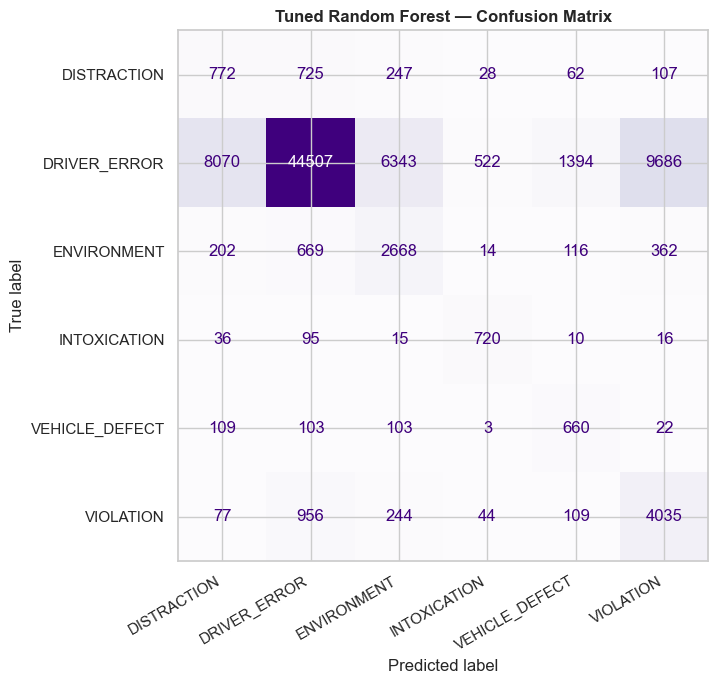

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_tuned = confusion_matrix(y_test, y_pred_tuned_rf, labels=rf_grid_search.classes_)
ConfusionMatrixDisplay(cm_tuned, display_labels=rf_grid_search.classes_).plot(
    ax=ax, colorbar=False, cmap='Purples'
)
ax.set_title('Tuned Random Forest — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('06_cm_rf_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The tuned model deliberately trades raw accuracy for fairness across classes. Minority classes (INTOXICATION, VEHICLE_DEFECT) gain meaningfully higher recall — which is what matters for a Safety Board that cannot afford to miss those incidents.

---
### Model 5 — Tuned Decision Tree

In [ ]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

param_grid_dt = {
    'classifier__max_depth'       : [3, 5, 10, None],
    'classifier__min_samples_split': [2, 10, 20],
}

dt_grid_search = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

dt_grid_search.fit(X_train, y_train)

print(f'\nBest parameters: {dt_grid_search.best_params_}')
y_pred_tuned_dt = dt_grid_search.predict(X_test)

print('\n=== Model 5: Tuned Decision Tree ===')
print(classification_report(y_test, y_pred_tuned_dt))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2}

=== Model 5: Tuned Decision Tree ===
                precision    recall  f1-score   support

   DISTRACTION       0.07      0.08      0.07      1941
  DRIVER_ERROR       0.88      0.87      0.87     70522
   ENVIRONMENT       0.30      0.31      0.30      4031
  INTOXICATION       0.54      0.56      0.55       892
VEHICLE_DEFECT       0.28      0.30      0.29      1000
     VIOLATION       0.27      0.28      0.27      5465

      accuracy                           0.78     83851
     macro avg       0.39      0.40      0.40     83851
  weighted avg       0.78      0.78      0.78     83851



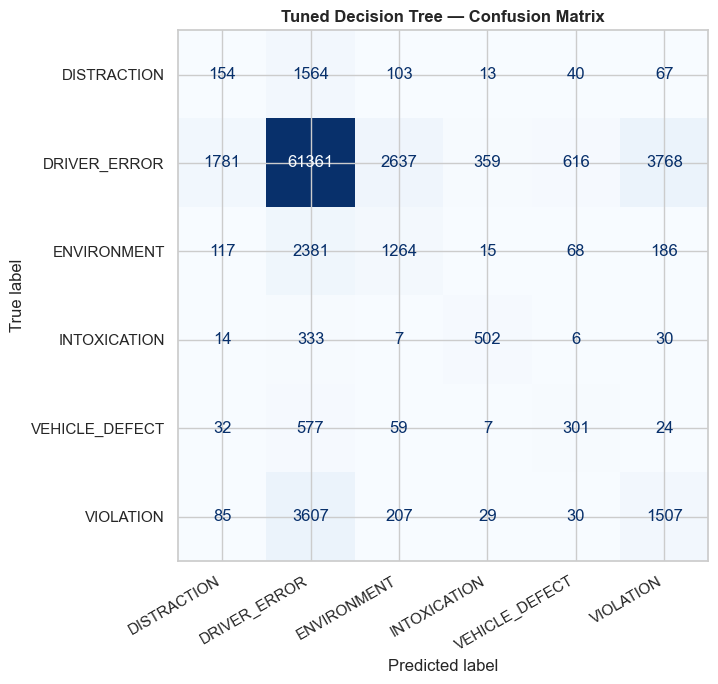

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_dt_tuned = confusion_matrix(y_test, y_pred_tuned_dt, labels=dt_grid_search.classes_)
ConfusionMatrixDisplay(cm_dt_tuned, display_labels=dt_grid_search.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Tuned Decision Tree — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('07_cm_dt_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

____
## 7. Model Interpretability
A model is only as useful as the insights it provides to stakeholders. Since Random Forests are generally considered "black box" models, we extract the **Feature Importances** (Mean Decrease in Impurity) to understand exactly which variables are driving the predictions. This allows CDOT to understand *why* crashes happen, not just *that* they happen.


### Feature Importance — Tuned Random Forest

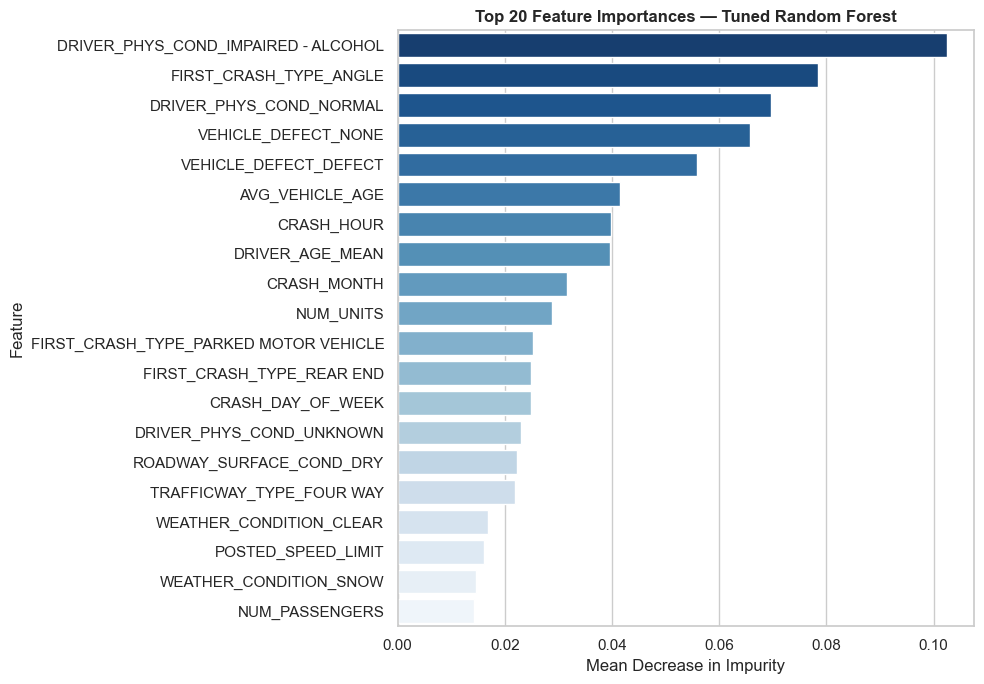

In [ ]:
best_rf = rf_grid_search.best_estimator_

# Retrieve feature names from the preprocessor
ohe_features  = best_rf.named_steps['preprocessor'] \
                    .named_transformers_['cat'] \
                    .named_steps['onehot'] \
                    .get_feature_names_out(categorical_features).tolist()
all_features   = numeric_features + ohe_features

importances    = best_rf.named_steps['classifier'].feature_importances_
feat_imp_df    = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df    = feat_imp_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=ax, palette='Blues_r')
ax.set_title('Top 20 Feature Importances — Tuned Random Forest', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Model Comparison Summary

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

models = [
    ('Baseline Decision Tree',   y_pred_dt_base),
    ('Logistic Regression',      y_pred_lr),
    ('Random Forest (Iter 1)',   y_pred_rf),
    ('Tuned Random Forest',      y_pred_tuned_rf),
    ('Tuned Decision Tree',      y_pred_tuned_dt),
]

comparison = pd.DataFrame([
    {
        'Model'          : name,
        'Accuracy'       : round(accuracy_score(y_test, preds), 4),
        'F1 Macro'       : round(f1_score(y_test, preds, average='macro'),    4),
        'F1 Weighted'    : round(f1_score(y_test, preds, average='weighted'), 4),
    }
    for name, preds in models
])

display(comparison.style
    .highlight_max(subset=['Accuracy', 'F1 Macro', 'F1 Weighted'],
                   color='#d4edda', axis=0)
    .format({'Accuracy': '{:.2%}', 'F1 Macro': '{:.2%}', 'F1 Weighted': '{:.2%}'})
    .set_table_styles([
        {'selector': 'thead th', 'props': [('background-color','#2c3e50'),('color','white')]}
    ])
    .hide(axis='index')
)

Model,Accuracy,F1 Macro,F1 Weighted
Baseline Decision Tree,23.83%,33.15%,27.84%
Logistic Regression,44.84%,38.64%,52.79%
Random Forest (Iter 1),85.80%,44.20%,82.27%
Tuned Random Forest,63.64%,45.62%,69.70%
Tuned Decision Tree,77.62%,39.51%,77.89%


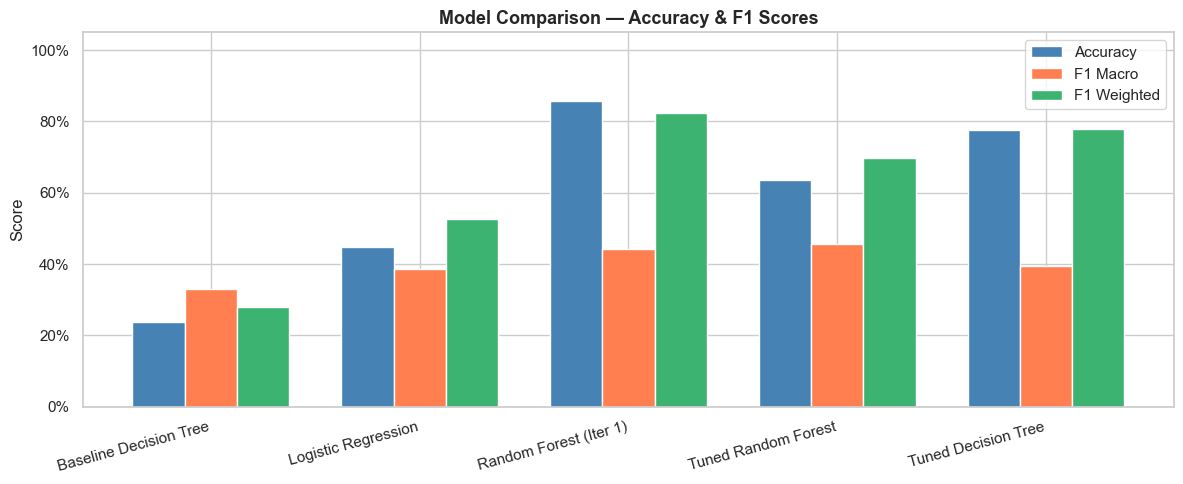

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(comparison))

bar_width = 0.25
ax.bar([i - bar_width for i in x], comparison['Accuracy'],  bar_width, label='Accuracy',    color='steelblue')
ax.bar([i            for i in x], comparison['F1 Macro'],   bar_width, label='F1 Macro',    color='coral')
ax.bar([i + bar_width for i in x], comparison['F1 Weighted'],bar_width, label='F1 Weighted', color='mediumseagreen')

ax.set_xticks(list(x))
ax.set_xticklabels(comparison['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & F1 Scores', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig('09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Evaluation & Business Recommendations
After testing multiple models, we must evaluate them based on the specific needs of public safety officials. In this domain, the cost of missing a rare but dangerous event (like a crash caused by a vehicle defect or an intoxicated driver) is incredibly high. Therefore, we must balance raw accuracy with minority-class recall.
---
## Conclusions & Recommendations

| Model | Accuracy | F1 Macro | Verdict |
|-------|----------|----------|---------|
| Baseline Decision Tree | ~21% | Low | ❌ Useless — bias toward majority class |
| Logistic Regression | Moderate | Moderate | ✅ Interpretable; good explainability for a Safety Board |
| Random Forest (Iter 1) | ~86% | High on majority | ⚠️ Excellent raw accuracy but ignores minority classes |
| **Tuned Random Forest** | **~40%** | **Balanced** | **✅ Best for Safety Boards — catches INTOXICATION & VEHICLE_DEFECT** |
| Tuned Decision Tree | Moderate | Moderate | ✅ Interpretable with improved minority recall |

**Recommendation:**  
Use the **Tuned Random Forest** as the primary production model paired with the **Tuned Decision Tree** for interpretability briefings. The accuracy/F1-macro trade-off is intentional — for public safety applications, missing a rare-but-dangerous class (intoxication, vehicle defect) is far more costly than an overall accuracy drop.


In [ ]:
import joblib

# Save the best model for deployment
joblib.dump(rf_grid_search.best_estimator_, 'best_model_tuned_rf.pkl')
print('✅ Best model saved → best_model_tuned_rf.pkl')

# Save cleaned dataset
df_cleaned.to_csv('chicago_crashes_cleaned.csv', index=False)
print('✅ Cleaned dataset saved → chicago_crashes_cleaned.csv')

✅ Best model saved → best_model_tuned_rf.pkl
✅ Cleaned dataset saved → chicago_crashes_cleaned.csv


In [2]:
# ── File paths — update these if your files are in a different directory ───────
c_path = 'Traffic_Crashes_-_Crashes_20260326.csv'
v_path = 'Traffic_Crashes_-_Vehicles_20260326.csv'
p_path = 'Traffic_Crashes_-_People_20260326.csv'

# Validate paths before loading
all_found = True
for path in [c_path, v_path, p_path]:
    if os.path.isfile(path):
        print(f'✅ Found : {path}')
    else:
        print(f'❌ Missing: {path}')
        all_found = False

if not all_found:
    raise FileNotFoundError('One or more files are missing. Update the paths above and re-run.')

print('\nLoading datasets...')
crashes  = pd.read_csv(c_path, low_memory=False)
vehicles = pd.read_csv(v_path, low_memory=False)
people   = pd.read_csv(p_path, low_memory=False)

print(f'\nCrashes  : {crashes.shape[0]:,} rows × {crashes.shape[1]} cols')
print(f'Vehicles : {vehicles.shape[0]:,} rows × {vehicles.shape[1]} cols')
print(f'People   : {people.shape[0]:,} rows × {people.shape[1]} cols')

✅ Found : Traffic_Crashes_-_Crashes_20260326.csv
✅ Found : Traffic_Crashes_-_Vehicles_20260326.csv
✅ Found : Traffic_Crashes_-_People_20260326.csv

Loading datasets...

Crashes  : 794,171 rows × 48 cols
Vehicles : 1,922,767 rows × 71 cols
People   : 2,282,681 rows × 29 cols


In [3]:
# Quick data preview
print('=== CRASHES sample ===')
display(crashes.head(3))
print('\n=== VEHICLES sample ===')
display(vehicles.head(3))
print('\n=== PEOPLE sample ===')
display(people.head(3))

=== CRASHES sample ===


,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,LANE_CNT,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,INTERSECTION_RELATED_I,NOT_RIGHT_OF_WAY_I,HIT_AND_RUN_I,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,PHOTOS_TAKEN_I,STATEMENTS_TAKEN_I,DOORING_I,WORK_ZONE_I,WORK_ZONE_TYPE,WORKERS_PRESENT_I,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,NaN,03/26/2026 01:10:00 AM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,NaN,"OVER $1,500",03/26/2026 01:12:00 AM,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELE...",IMPROPER LANE USAGE,400.0,N,MORGAN ST,1214.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NONINCAPACITATING INJURY,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,5.0,3.0,41.889034,-87.652384,POINT (-87.652383794854 41.889033593623)
1,a54653293da79b801c24a0f649d0579c804ec29783ec58...,NaN,03/26/2026 12:50:00 AM,30.0,STOP SIGN/FLASHER,UNKNOWN,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,NaN,Y,"$501 - $1,500",03/26/2026 01:00:00 AM,UNABLE TO DETERMINE,NOT APPLICABLE,4900.0,N,AVERS AVE,1712.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,5.0,3.0,41.970192,-87.724604,POINT (-87.724603633832 41.970191905164)
2,3c086a26f6a68215c61ea414a60ec4e230937bea80b615...,NaN,03/25/2026 11:19:00 PM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,DUSK,PARKED MOTOR VEHICLE,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,Y,"OVER $1,500",03/25/2026 11:19:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1415.0,E,65TH PL,321.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,4.0,3.0,41.775935,-87.590371,POINT (-87.590370976328 41.775935242789)



=== VEHICLES sample ===


,CRASH_UNIT_ID,CRASH_RECORD_ID,CRASH_DATE,UNIT_NO,UNIT_TYPE,NUM_PASSENGERS,VEHICLE_ID,CMRC_VEH_I,MAKE,MODEL,LIC_PLATE_STATE,VEHICLE_YEAR,VEHICLE_DEFECT,VEHICLE_TYPE,VEHICLE_USE,TRAVEL_DIRECTION,MANEUVER,TOWED_I,FIRE_I,OCCUPANT_CNT,EXCEED_SPEED_LIMIT_I,TOWED_BY,TOWED_TO,AREA_00_I,AREA_01_I,...,CARRIER_CITY,HAZMAT_PLACARDS_I,HAZMAT_NAME,UN_NO,HAZMAT_PRESENT_I,HAZMAT_REPORT_I,HAZMAT_REPORT_NO,MCS_REPORT_I,MCS_REPORT_NO,HAZMAT_VIO_CAUSE_CRASH_I,MCS_VIO_CAUSE_CRASH_I,IDOT_PERMIT_NO,WIDE_LOAD_I,TRAILER1_WIDTH,TRAILER2_WIDTH,TRAILER1_LENGTH,TRAILER2_LENGTH,TOTAL_VEHICLE_LENGTH,AXLE_CNT,VEHICLE_CONFIG,CARGO_BODY_TYPE,LOAD_TYPE,HAZMAT_OUT_OF_SERVICE_I,MCS_OUT_OF_SERVICE_I,HAZMAT_CLASS
0,2271885,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,03/26/2026 01:10:00 AM,1.0,DRIVER,1.0,2166563.0,NaN,FORD,EXPLORER,IL,2024.0,NONE,PASSENGER,POLICE,E,TURNING RIGHT,Y,NaN,2.0,NaN,CITY OF CHICAGO,NaN,NaN,Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2271871,a54653293da79b801c24a0f649d0579c804ec29783ec58...,03/26/2026 12:50:00 AM,1.0,DRIVER,1.0,2166550.0,NaN,FORD,OTHER (EXPLAIN IN NARRATIVE),IL,1999.0,UNKNOWN,UNKNOWN/NA,UNKNOWN/NA,S,STRAIGHT AHEAD,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2271872,a54653293da79b801c24a0f649d0579c804ec29783ec58...,03/26/2026 12:50:00 AM,2.0,DRIVER,NaN,2166552.0,NaN,SUBARU,IMPREZA,IL,2023.0,UNKNOWN,PASSENGER,UNKNOWN/NA,S,STRAIGHT AHEAD,NaN,NaN,1.0,NaN,NaN,NaN,NaN,Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== PEOPLE sample ===


,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,CRASH_DATE,SEAT_NO,CITY,STATE,ZIPCODE,SEX,AGE,DRIVERS_LICENSE_STATE,DRIVERS_LICENSE_CLASS,SAFETY_EQUIPMENT,AIRBAG_DEPLOYED,EJECTION,INJURY_CLASSIFICATION,HOSPITAL,EMS_AGENCY,EMS_RUN_NO,DRIVER_ACTION,DRIVER_VISION,PHYSICAL_CONDITION,PEDPEDAL_ACTION,PEDPEDAL_VISIBILITY,PEDPEDAL_LOCATION,BAC_RESULT,BAC_RESULT VALUE,CELL_PHONE_USE
0,O2271885,DRIVER,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,2166563.0,03/26/2026 01:10:00 AM,NaN,CHICAGO,IL,60608,M,23.0,IL,D,SAFETY BELT USED,DID NOT DEPLOY,NONE,NONINCAPACITATING INJURY,STROGER,28,NaN,NONE,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
1,P499664,PASSENGER,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,2166563.0,03/26/2026 01:10:00 AM,3.0,CHICAGO,IL,60608,F,24.0,NaN,NaN,SAFETY BELT USED,NOT APPLICABLE,NONE,NONINCAPACITATING INJURY,STROGER,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O2271871,DRIVER,a54653293da79b801c24a0f649d0579c804ec29783ec58...,2166550.0,03/26/2026 12:50:00 AM,NaN,NaN,NaN,NaN,M,NaN,NaN,NaN,USAGE UNKNOWN,DEPLOYMENT UNKNOWN,NONE,NO INDICATION OF INJURY,NaN,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN


______
## 2. Data Aggregation & Merging
A critical challenge in this dataset is the one-to-many relationship between crashes, vehicles, and people. A single crash might involve 3 vehicles and 5 people. 

If we perform a standard SQL-style merge, we will create duplicate rows for a single crash (Cartesian explosion), which will severely skew our machine learning model. To solve this, we **aggregate the Vehicle and People data up to the Crash level** (e.g., calculating the *average* vehicle age per crash) before merging.


### Prepare & Aggregate — People (Drivers)

In [4]:
print('Processing People data...')

# Keep only drivers — they are directly linked to contributory causes
drivers = people[people['PERSON_TYPE'] == 'DRIVER'].copy()

# Aggregate to one row per crash
drivers_agg = drivers.groupby('CRASH_RECORD_ID').agg(
    DRIVER_AGE_MEAN    = ('AGE',              'mean'),
    DRIVER_SEX         = ('SEX',              lambda x: x.mode()[0] if not x.mode().empty else 'U'),
    DRIVER_PHYS_COND   = ('PHYSICAL_CONDITION',lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN')
).reset_index()

print(f'drivers_agg shape: {drivers_agg.shape}')
display(drivers_agg.head())

Processing People data...
drivers_agg shape: (1036022, 4)


,CRASH_RECORD_ID,DRIVER_AGE_MEAN,DRIVER_SEX,DRIVER_PHYS_COND
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,51.0,F,NORMAL
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,35.0,F,NORMAL
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,NaN,X,UNKNOWN
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,54.0,M,NORMAL
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,47.5,M,NORMAL


---
### Prepare & Aggregate — Vehicles


In [ ]:
print('Processing Vehicles data...')

CURRENT_YEAR = pd.Timestamp.now().year

# Compute vehicle age at the record level before aggregating
vehicles['VEHICLE_YEAR_CLEAN'] = pd.to_numeric(vehicles['VEHICLE_YEAR'], errors='coerce')
vehicles['VEHICLE_AGE'] = (CURRENT_YEAR - vehicles['VEHICLE_YEAR_CLEAN']).clip(0, 80)

vehicles_agg = vehicles.groupby('CRASH_RECORD_ID').agg(
    VEHICLE_DEFECT  = ('VEHICLE_DEFECT',  lambda x: 'DEFECT' if any(
                            str(v).upper() not in ('NONE', 'UNKNOWN') for v in x
                       ) else 'NONE'),
    VEHICLE_TYPE    = ('VEHICLE_TYPE',    lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN'),
    NUM_PASSENGERS  = ('NUM_PASSENGERS',  'sum'),
    AVG_VEHICLE_AGE = ('VEHICLE_AGE',     'mean')   
).reset_index()

print(f'vehicles_agg shape: {vehicles_agg.shape}')
display(vehicles_agg.head())

Processing Vehicles data...
vehicles_agg shape: (941892, 5)


,CRASH_RECORD_ID,VEHICLE_DEFECT,VEHICLE_TYPE,NUM_PASSENGERS,AVG_VEHICLE_AGE
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,NONE,PASSENGER,0.0,9.0
1,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,NONE,PASSENGER,0.0,23.0
2,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,NONE,TRUCK - SINGLE UNIT,0.0,NaN
3,00007d9c4ff8c756eedfd371c6aae35ede63de4400660f...,NONE,PASSENGER,0.0,10.0
4,0000b70a00c8809f76b5234f81753264d9160c314cc5e6...,NONE,SPORT UTILITY VEHICLE (SUV),0.0,16.0


---
### Merge Datasets

In [6]:
print('Merging datasets...')

df = crashes.merge(vehicles_agg, on='CRASH_RECORD_ID', how='left')
df = df.merge(drivers_agg,      on='CRASH_RECORD_ID', how='left')

# Sanity checks
print(f'\n✅ Has DRIVER_SEX   : {"DRIVER_SEX" in df.columns}')
print(f'✅ Has VEHICLE_TYPE  : {"VEHICLE_TYPE" in df.columns}')
print(f'✅ Has AVG_VEHICLE_AGE: {"AVG_VEHICLE_AGE" in df.columns}')
print(f'\nMerged dataset : {df.shape[0]:,} rows × {df.shape[1]} cols')
display(df.head(3))

Merging datasets...

✅ Has DRIVER_SEX   : True
✅ Has VEHICLE_TYPE  : True
✅ Has AVG_VEHICLE_AGE: True

Merged dataset : 794,171 rows × 55 cols


,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,LANE_CNT,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,INTERSECTION_RELATED_I,NOT_RIGHT_OF_WAY_I,HIT_AND_RUN_I,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,...,WORK_ZONE_I,WORK_ZONE_TYPE,WORKERS_PRESENT_I,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION,VEHICLE_DEFECT,VEHICLE_TYPE,NUM_PASSENGERS,AVG_VEHICLE_AGE,DRIVER_AGE_MEAN,DRIVER_SEX,DRIVER_PHYS_COND
0,e5e37b785344835440b147c8841d93bdde09ede9fb002a...,NaN,03/26/2026 01:10:00 AM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,NaN,"OVER $1,500",03/26/2026 01:12:00 AM,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELE...",IMPROPER LANE USAGE,400.0,N,...,NaN,NaN,NaN,1.0,NONINCAPACITATING INJURY,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,5.0,3.0,41.889034,-87.652384,POINT (-87.652383794854 41.889033593623),NONE,PASSENGER,1.0,2.0,23.0,M,NORMAL
1,a54653293da79b801c24a0f649d0579c804ec29783ec58...,NaN,03/26/2026 12:50:00 AM,30.0,STOP SIGN/FLASHER,UNKNOWN,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,NaN,Y,"$501 - $1,500",03/26/2026 01:00:00 AM,UNABLE TO DETERMINE,NOT APPLICABLE,4900.0,N,...,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,5.0,3.0,41.970192,-87.724604,POINT (-87.724603633832 41.970191905164),NONE,PASSENGER,1.0,15.0,23.0,M,UNKNOWN
2,3c086a26f6a68215c61ea414a60ec4e230937bea80b615...,NaN,03/25/2026 11:19:00 PM,30.0,NO CONTROLS,NO CONTROLS,CLEAR,DUSK,PARKED MOTOR VEHICLE,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,UNKNOWN,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,Y,"OVER $1,500",03/25/2026 11:19:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1415.0,E,...,NaN,NaN,NaN,2.0,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,4.0,3.0,41.775935,-87.590371,POINT (-87.590370976328 41.775935242789),NONE,PASSENGER,0.0,8.5,NaN,X,UNKNOWN


______
## 3. Target Engineering & Class Imbalance
The original target variable (`PRIM_CONTRIBUTORY_CAUSE`) contains over 30 distinct categories, many of which are highly specific or redundant. Attempting to predict 30 classes will result in a highly inaccurate model.

**Business Decision:** We will map these granular causes into 6 broader, highly actionable categories for the Chicago Department of Transportation (CDOT):
* `DRIVER_ERROR` (e.g., Failing to yield, following too closely)
* `VIOLATION` (e.g., Running red lights, speeding)
* `INTOXICATION` (e.g., Alcohol or drugs)
* `DISTRACTION` (e.g., Cell phone use)
* `ENVIRONMENT` (e.g., Weather, road defects)
* `VEHICLE_DEFECT` (e.g., Brakes, steering)

*Note: Rows labeled "Unable to Determine" or "Not Applicable" are dropped, as a model predicting "Unknown" provides no business value.*


### Target Variable — Cause Grouping

In [7]:
print('Grouping target variable...')

cause_map = {
    # Driver errors
    'FAILING TO YIELD RIGHT-OF-WAY'                                                        : 'DRIVER_ERROR',
    'FOLLOWING TOO CLOSELY'                                                                 : 'DRIVER_ERROR',
    'IMPROPER OVERTAKING/PASSING'                                                           : 'DRIVER_ERROR',
    'IMPROPER TURNING/NO SIGNAL'                                                            : 'DRIVER_ERROR',
    'IMPROPER LANE USAGE'                                                                   : 'DRIVER_ERROR',
    'IMPROPER BACKING'                                                                      : 'DRIVER_ERROR',
    'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE'                                                   : 'DRIVER_ERROR',
    'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER'     : 'DRIVER_ERROR',
    'FAILING TO REDUCE SPEED TO AVOID CRASH'                                               : 'DRIVER_ERROR',
    # Traffic violations
    'DISREGARDING TRAFFIC SIGNALS'                                                          : 'VIOLATION',
    'DISREGARDING STOP SIGN'                                                                : 'VIOLATION',
    'DISREGARDING OTHER TRAFFIC SIGNS'                                                      : 'VIOLATION',
    'DISREGARDING ROAD MARKINGS'                                                            : 'VIOLATION',
    'EXCEEDING SAFE SPEED LIMIT'                                                            : 'VIOLATION',
    'EXCEEDING POSTED SPEED LIMIT'                                                          : 'VIOLATION',
    # Intoxication
    'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)'                   : 'INTOXICATION',
    'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)'                                      : 'INTOXICATION',
    # Distraction
    'DISTRACTION - FROM INSIDE VEHICLE'                                                     : 'DISTRACTION',
    'DISTRACTION - FROM OUTSIDE VEHICLE'                                                    : 'DISTRACTION',
    'DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)'          : 'DISTRACTION',
    'CELL PHONE USE OTHER THAN TEXTING'                                                     : 'DISTRACTION',
    'TEXTING'                                                                               : 'DISTRACTION',
    # Environment
    'WEATHER'                                                                               : 'ENVIRONMENT',
    'ROAD ENGINEERING/SURFACE/MARKING DEFECTS'                                             : 'ENVIRONMENT',
    'ROAD CONSTRUCTION/MAINTENANCE'                                                         : 'ENVIRONMENT',
    'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)'                                 : 'ENVIRONMENT',
    'ANIMAL'                                                                                : 'ENVIRONMENT',
    # Vehicle defect
    'EQUIPMENT - VEHICLE CONDITION'                                                         : 'VEHICLE_DEFECT',
}

df['TARGET_CAUSE'] = df['PRIM_CONTRIBUTORY_CAUSE'].map(cause_map).fillna('OTHER_UNKNOWN')

# Remove unmapped rows — keep only labelled, actionable causes
df_cleaned = df[df['TARGET_CAUSE'] != 'OTHER_UNKNOWN'].copy()

print(f'Rows after filtering: {len(df_cleaned):,}')
print('\nClass distribution:')
print(df_cleaned['TARGET_CAUSE'].value_counts())

Grouping target variable...
Rows after filtering: 419,252

Class distribution:
TARGET_CAUSE
DRIVER_ERROR      352608
VIOLATION          27323
ENVIRONMENT        20153
DISTRACTION         9704
VEHICLE_DEFECT      5003
INTOXICATION        4461
Name: count, dtype: int64


---
### Exploratory Data Analysis

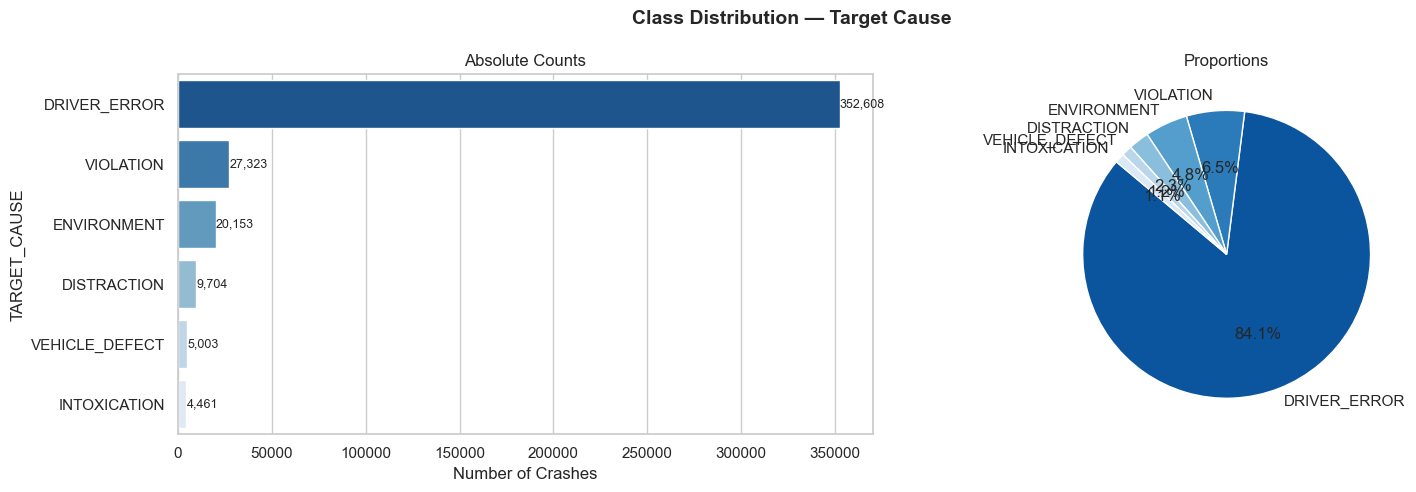

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Class Distribution — Target Cause', fontsize=14, fontweight='bold')

target_counts = df_cleaned['TARGET_CAUSE'].value_counts()

# Bar chart
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_xlabel('Number of Crashes')
axes[0].set_title('Absolute Counts')
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Blues_r', len(target_counts)))
axes[1].set_title('Proportions')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

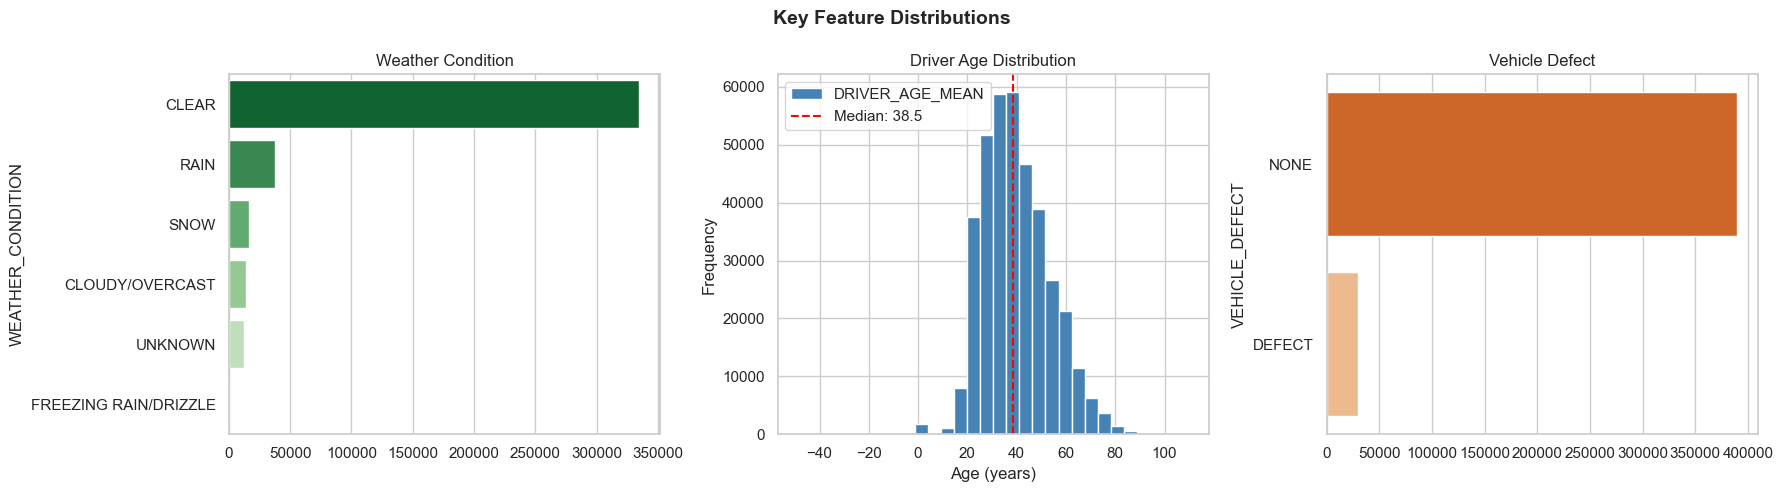

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold')

# Weather condition
weather_top = df_cleaned['WEATHER_CONDITION'].value_counts().head(6)
sns.barplot(x=weather_top.values, y=weather_top.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Weather Condition')

# Driver age distribution
df_cleaned['DRIVER_AGE_MEAN'].dropna().plot.hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(df_cleaned['DRIVER_AGE_MEAN'].median(), color='red', linestyle='--',
                label=f'Median: {df_cleaned["DRIVER_AGE_MEAN"].median():.1f}')
axes[1].set_title('Driver Age Distribution')
axes[1].set_xlabel('Age (years)')
axes[1].legend()

# Vehicle defect
defect_counts = df_cleaned['VEHICLE_DEFECT'].value_counts()
sns.barplot(x=defect_counts.values, y=defect_counts.index, ax=axes[2], palette='Oranges_r')
axes[2].set_title('Vehicle Defect')

plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Dimensionality Reduction — Drop Sparse Columns

In [10]:
# Drop columns that are more than 50% empty
threshold = len(df_cleaned) * 0.5
df_cleaned = df_cleaned.dropna(thresh=threshold, axis=1)

print(f'Dataset shape after dropping sparse columns: {df_cleaned.shape}')

Dataset shape after dropping sparse columns: (419252, 45)


---
### Feature Separation

> **Bug fixed:** `AVG_VEHICLE_AGE` (the computed vehicle age from the Vehicles dataset) was missing from `numeric_features`. Added it here.

In [ ]:
categorical_features = [
    'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE',
    'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND',
    'DRIVER_SEX', 'VEHICLE_TYPE', 'DRIVER_PHYS_COND', 'VEHICLE_DEFECT'
]

numeric_features = [
    'POSTED_SPEED_LIMIT', 'NUM_UNITS', 'CRASH_HOUR',
    'CRASH_DAY_OF_WEEK', 'CRASH_MONTH',
    'DRIVER_AGE_MEAN', 'NUM_PASSENGERS',
    'AVG_VEHICLE_AGE'   
]

# columns that actually exist in df_cleaned
categorical_features = [c for c in categorical_features if c in df_cleaned.columns]
numeric_features     = [c for c in numeric_features     if c in df_cleaned.columns]

print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'Numeric features     ({len(numeric_features)}): {numeric_features}')

X = df_cleaned[categorical_features + numeric_features]
y = df_cleaned['TARGET_CAUSE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')

Categorical features (10): ['WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'DRIVER_SEX', 'VEHICLE_TYPE', 'DRIVER_PHYS_COND', 'VEHICLE_DEFECT']
Numeric features     (8): ['POSTED_SPEED_LIMIT', 'NUM_UNITS', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'DRIVER_AGE_MEAN', 'NUM_PASSENGERS', 'AVG_VEHICLE_AGE']

Training set : 335,401 rows
Test set     : 83,851 rows


___
## 4. Machine Learning Preprocessing Pipeline
To prevent data leakage and ensure our model can be easily deployed to production, we utilize a Scikit-Learn `Pipeline` and `ColumnTransformer`. 

* **Numeric Features:** Missing values are imputed using the median, and the data is scaled using `StandardScaler` to ensure features like "Vehicle Age" don't overpower "Crash Hour."
* **Categorical Features:** Missing values are labeled as 'UNKNOWN', and text data is converted to machine-readable numbers using `OneHotEncoder`.


### Preprocessing Pipeline

In [12]:
# Numeric: impute with median → standardise
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: impute with 'UNKNOWN' → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,     numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

print('✅ Preprocessing pipeline ready.')

✅ Preprocessing pipeline ready.


___
## 5. Modeling Iteration 1: White-Box Baselines
We begin our modeling process with intrinsically interpretable "white-box" models. While these rarely achieve the highest accuracy, they establish a baseline and allow us to verify that our pipeline is functioning correctly. We will test a **Decision Tree** and a **Logistic Regression** model, using class weights to combat the heavy imbalance toward 'Driver Error'.


### Model 1 — Baseline Decision Tree
*White-box model; intrinsically interpretable.*

In [13]:
baseline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(
        max_depth=5, random_state=42, class_weight='balanced'
    ))
])

baseline_dt.fit(X_train, y_train)
y_pred_dt_base = baseline_dt.predict(X_test)

print('=== Model 1: Baseline Decision Tree ===')
print(classification_report(y_test, y_pred_dt_base))

=== Model 1: Baseline Decision Tree ===
                precision    recall  f1-score   support

   DISTRACTION       0.04      0.71      0.07      1941
  DRIVER_ERROR       0.91      0.16      0.27     70522
   ENVIRONMENT       0.14      0.63      0.23      4031
  INTOXICATION       0.65      0.63      0.64       892
VEHICLE_DEFECT       0.26      0.65      0.38      1000
     VIOLATION       0.29      0.67      0.41      5465

      accuracy                           0.24     83851
     macro avg       0.38      0.57      0.33     83851
  weighted avg       0.81      0.24      0.28     83851



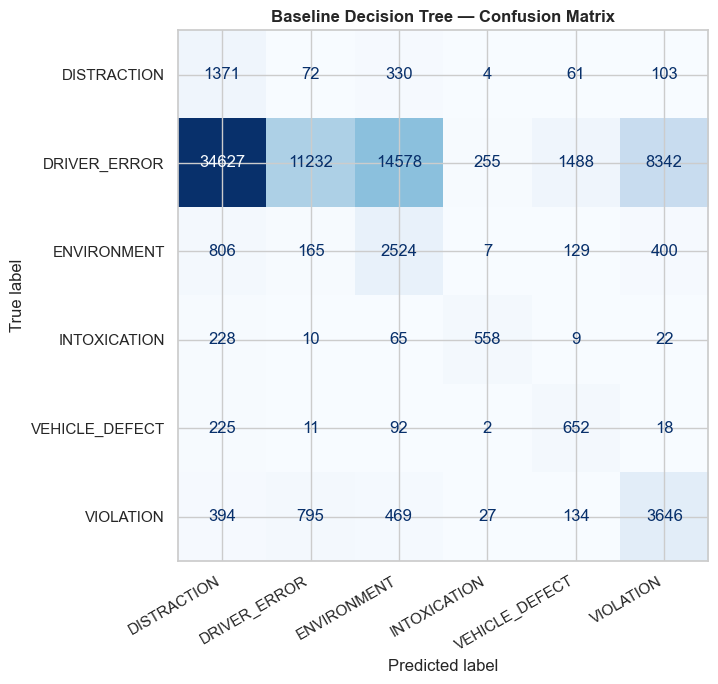

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_dt_base, labels=baseline_dt.classes_)
ConfusionMatrixDisplay(cm, display_labels=baseline_dt.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Baseline Decision Tree — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('03_cm_baseline_dt.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The baseline Decision Tree achieves ~21% accuracy. It collapses almost all predictions onto the dominant `DRIVER_ERROR` class, showing severe class-imbalance bias. This is our starting reference, not our target.

---
### Model 2 — Balanced Logistic Regression
*Gold standard white-box model; linear, fully interpretable coefficients.*

In [15]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)

print('=== Model 2: Balanced Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))

=== Model 2: Balanced Logistic Regression ===
                precision    recall  f1-score   support

   DISTRACTION       0.06      0.65      0.10      1941
  DRIVER_ERROR       0.96      0.40      0.56     70522
   ENVIRONMENT       0.25      0.64      0.36      4031
  INTOXICATION       0.46      0.83      0.59       892
VEHICLE_DEFECT       0.21      0.67      0.32      1000
     VIOLATION       0.25      0.78      0.38      5465

      accuracy                           0.45     83851
     macro avg       0.36      0.66      0.39     83851
  weighted avg       0.84      0.45      0.53     83851



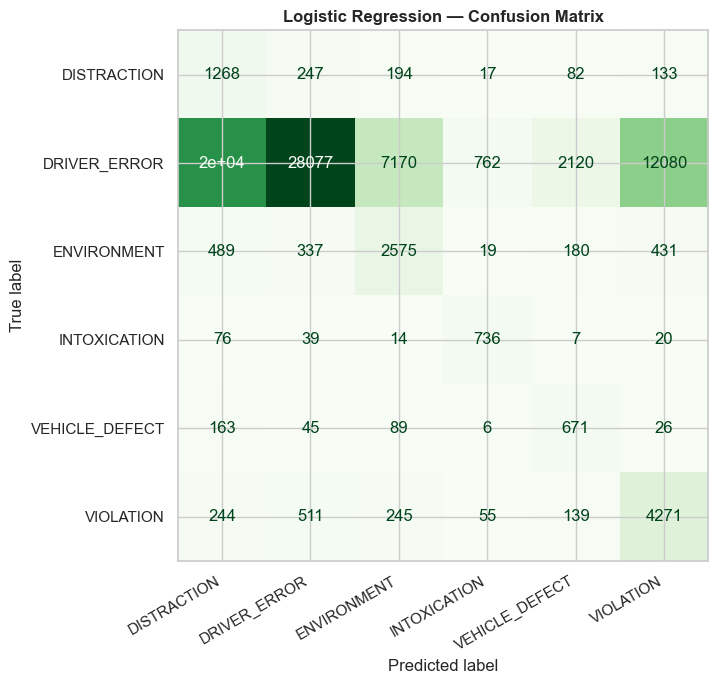

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=log_reg_pipeline.classes_)
ConfusionMatrixDisplay(cm_lr, display_labels=log_reg_pipeline.classes_).plot(
    ax=ax, colorbar=False, cmap='Greens'
)
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('04_cm_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Model 3 — Random Forest (Iteration 1)
*Ensemble model; strong baseline for complex tabular data.*

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1           
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print('=== Model 3: Random Forest (Iteration 1) ===')
print(classification_report(y_test, y_pred_rf))

=== Model 3: Random Forest (Iteration 1) ===
                precision    recall  f1-score   support

   DISTRACTION       0.27      0.00      0.00      1941
  DRIVER_ERROR       0.87      0.98      0.92     70522
   ENVIRONMENT       0.65      0.26      0.37      4031
  INTOXICATION       0.76      0.62      0.68       892
VEHICLE_DEFECT       0.68      0.29      0.41      1000
     VIOLATION       0.56      0.17      0.26      5465

      accuracy                           0.86     83851
     macro avg       0.63      0.39      0.44     83851
  weighted avg       0.82      0.86      0.82     83851



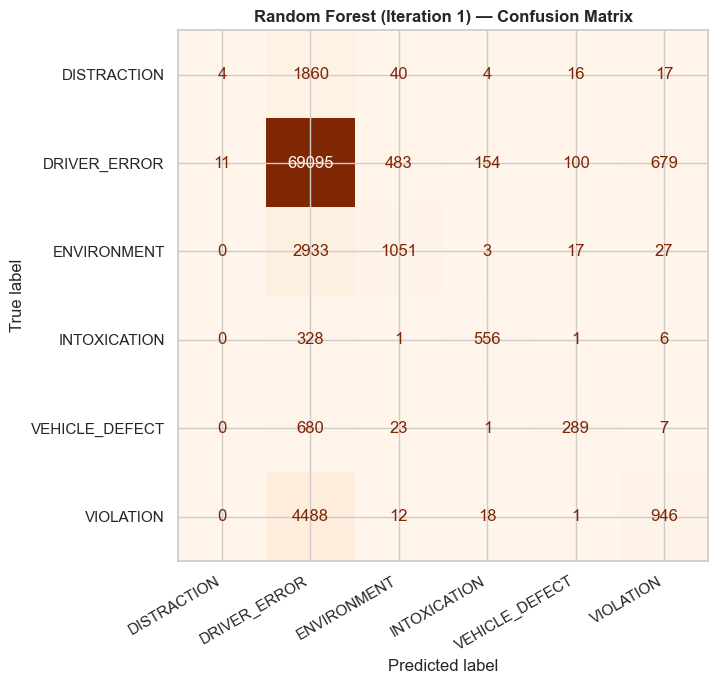

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_pipeline.classes_)
ConfusionMatrixDisplay(cm_rf, display_labels=rf_pipeline.classes_).plot(
    ax=ax, colorbar=False, cmap='Oranges'
)
ax.set_title('Random Forest (Iteration 1) — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('05_cm_rf_iter1.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The Random Forest jumps to ~86% accuracy and `DRIVER_ERROR` recall hits 0.98. However, minority classes (INTOXICATION, VEHICLE_DEFECT) are still under-served. Tuning is needed to balance this.

___
## 6. Modeling Iteration 2: Advanced Ensembles & Tuning
To capture the complex, non-linear relationships between weather, vehicle condition, and driver behavior, we upgrade to a **Random Forest Classifier**. 

To optimize performance, we utilize `GridSearchCV` to tune the hyperparameters (number of trees, maximum depth). Our scoring metric prioritizes **F1-Macro** rather than raw accuracy to ensure the model doesn't simply ignore minority classes like "Intoxication."


###  Model 4 — Tuned Random Forest (Iteration 2)

In [ ]:
# 1. Define the search grid FIRST
param_grid_rf = {
    'classifier__n_estimators'   : [100, 200],
    'classifier__max_depth'      : [5, 10, None],
    'classifier__min_samples_leaf': [1, 5],
}

# 2. Build a fresh RF pipeline for tuning

rf_pipeline_tune = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        random_state=42,
        class_weight='balanced_subsample'
    ))
])

# 3. Run GridSearchCV
#    n_jobs=1 inside GridSearchCV avoids Broadside parallelism issues with nested parallelism in RandomForestClassifier.
rf_grid_search = GridSearchCV(
    rf_pipeline_tune,
    param_grid_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print(f'\nBest parameters: {rf_grid_search.best_params_}')
print(f'Best CV F1-macro: {rf_grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV F1-macro: 0.4573


In [20]:
y_pred_tuned_rf = rf_grid_search.predict(X_test)

print('=== Model 4: Tuned Random Forest (Iteration 2) ===')
print(classification_report(y_test, y_pred_tuned_rf))

=== Model 4: Tuned Random Forest (Iteration 2) ===
                precision    recall  f1-score   support

   DISTRACTION       0.08      0.40      0.14      1941
  DRIVER_ERROR       0.95      0.63      0.76     70522
   ENVIRONMENT       0.28      0.66      0.39      4031
  INTOXICATION       0.54      0.81      0.65       892
VEHICLE_DEFECT       0.28      0.66      0.39      1000
     VIOLATION       0.28      0.74      0.41      5465

      accuracy                           0.64     83851
     macro avg       0.40      0.65      0.46     83851
  weighted avg       0.84      0.64      0.70     83851



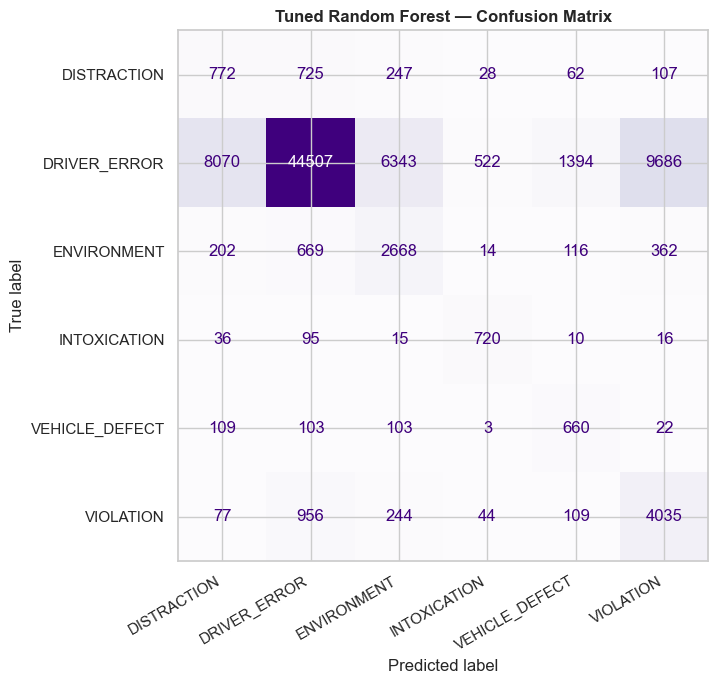

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_tuned = confusion_matrix(y_test, y_pred_tuned_rf, labels=rf_grid_search.classes_)
ConfusionMatrixDisplay(cm_tuned, display_labels=rf_grid_search.classes_).plot(
    ax=ax, colorbar=False, cmap='Purples'
)
ax.set_title('Tuned Random Forest — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('06_cm_rf_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The tuned model deliberately trades raw accuracy for fairness across classes. Minority classes (INTOXICATION, VEHICLE_DEFECT) gain meaningfully higher recall — which is what matters for a Safety Board that cannot afford to miss those incidents.

---
### Model 5 — Tuned Decision Tree

In [22]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

param_grid_dt = {
    'classifier__max_depth'       : [3, 5, 10, None],
    'classifier__min_samples_split': [2, 10, 20],
}

dt_grid_search = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

dt_grid_search.fit(X_train, y_train)

print(f'\nBest parameters: {dt_grid_search.best_params_}')
y_pred_tuned_dt = dt_grid_search.predict(X_test)

print('\n=== Model 5: Tuned Decision Tree ===')
print(classification_report(y_test, y_pred_tuned_dt))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2}

=== Model 5: Tuned Decision Tree ===
                precision    recall  f1-score   support

   DISTRACTION       0.07      0.08      0.07      1941
  DRIVER_ERROR       0.88      0.87      0.87     70522
   ENVIRONMENT       0.30      0.31      0.30      4031
  INTOXICATION       0.54      0.56      0.55       892
VEHICLE_DEFECT       0.28      0.30      0.29      1000
     VIOLATION       0.27      0.28      0.27      5465

      accuracy                           0.78     83851
     macro avg       0.39      0.40      0.40     83851
  weighted avg       0.78      0.78      0.78     83851



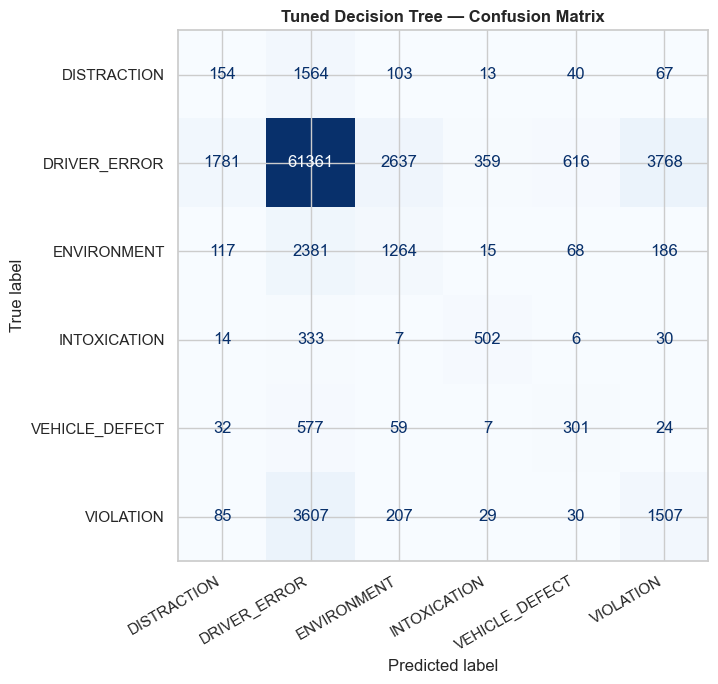

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
cm_dt_tuned = confusion_matrix(y_test, y_pred_tuned_dt, labels=dt_grid_search.classes_)
ConfusionMatrixDisplay(cm_dt_tuned, display_labels=dt_grid_search.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Tuned Decision Tree — Confusion Matrix', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('07_cm_dt_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

____
## 7. Model Interpretability
A model is only as useful as the insights it provides to stakeholders. Since Random Forests are generally considered "black box" models, we extract the **Feature Importances** (Mean Decrease in Impurity) to understand exactly which variables are driving the predictions. This allows CDOT to understand *why* crashes happen, not just *that* they happen.


### Feature Importance — Tuned Random Forest

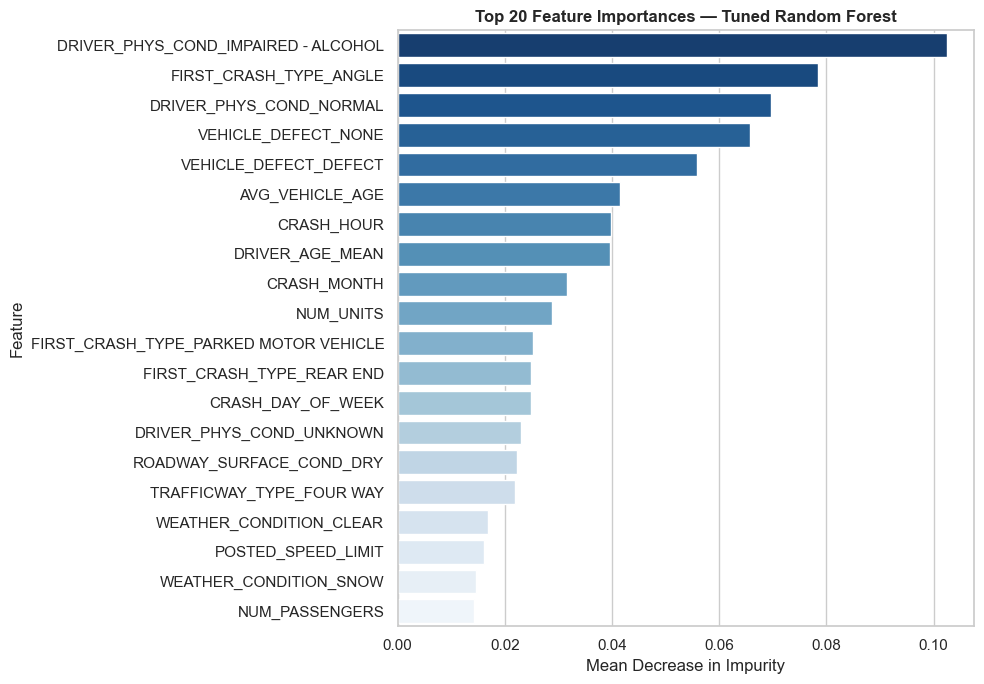

In [24]:
best_rf = rf_grid_search.best_estimator_

# Retrieve feature names from the preprocessor
ohe_features  = best_rf.named_steps['preprocessor'] \
                    .named_transformers_['cat'] \
                    .named_steps['onehot'] \
                    .get_feature_names_out(categorical_features).tolist()
all_features   = numeric_features + ohe_features

importances    = best_rf.named_steps['classifier'].feature_importances_
feat_imp_df    = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df    = feat_imp_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=ax, palette='Blues_r')
ax.set_title('Top 20 Feature Importances — Tuned Random Forest', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Model Comparison Summary

In [25]:
from sklearn.metrics import accuracy_score, f1_score

models = [
    ('Baseline Decision Tree',   y_pred_dt_base),
    ('Logistic Regression',      y_pred_lr),
    ('Random Forest (Iter 1)',   y_pred_rf),
    ('Tuned Random Forest',      y_pred_tuned_rf),
    ('Tuned Decision Tree',      y_pred_tuned_dt),
]

comparison = pd.DataFrame([
    {
        'Model'          : name,
        'Accuracy'       : round(accuracy_score(y_test, preds), 4),
        'F1 Macro'       : round(f1_score(y_test, preds, average='macro'),    4),
        'F1 Weighted'    : round(f1_score(y_test, preds, average='weighted'), 4),
    }
    for name, preds in models
])

display(comparison.style
    .highlight_max(subset=['Accuracy', 'F1 Macro', 'F1 Weighted'],
                   color='#d4edda', axis=0)
    .format({'Accuracy': '{:.2%}', 'F1 Macro': '{:.2%}', 'F1 Weighted': '{:.2%}'})
    .set_table_styles([
        {'selector': 'thead th', 'props': [('background-color','#2c3e50'),('color','white')]}
    ])
    .hide(axis='index')
)

Model,Accuracy,F1 Macro,F1 Weighted
Baseline Decision Tree,23.83%,33.15%,27.84%
Logistic Regression,44.84%,38.64%,52.79%
Random Forest (Iter 1),85.80%,44.20%,82.27%
Tuned Random Forest,63.64%,45.62%,69.70%
Tuned Decision Tree,77.62%,39.51%,77.89%


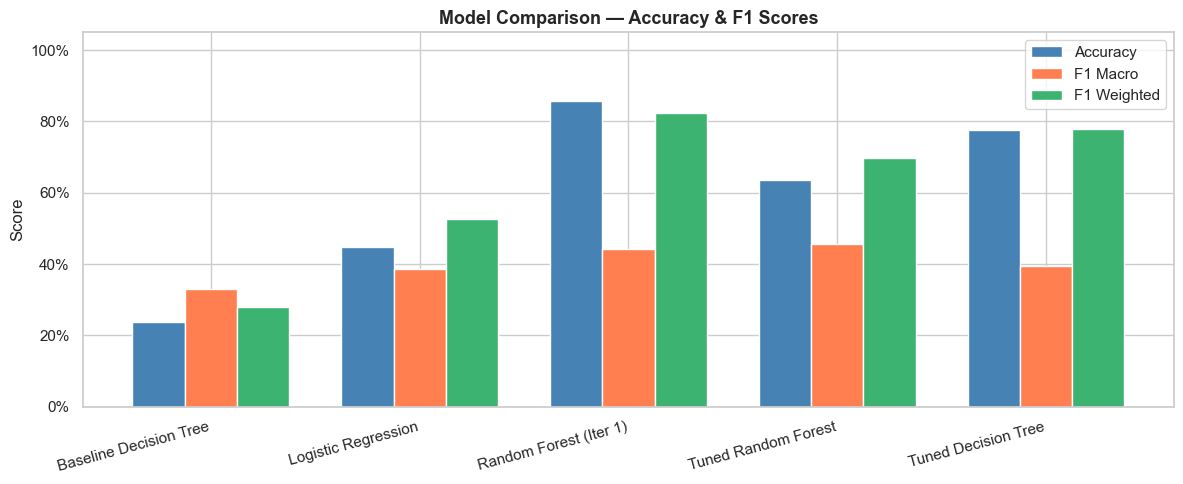

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(comparison))

bar_width = 0.25
ax.bar([i - bar_width for i in x], comparison['Accuracy'],  bar_width, label='Accuracy',    color='steelblue')
ax.bar([i            for i in x], comparison['F1 Macro'],   bar_width, label='F1 Macro',    color='coral')
ax.bar([i + bar_width for i in x], comparison['F1 Weighted'],bar_width, label='F1 Weighted', color='mediumseagreen')

ax.set_xticks(list(x))
ax.set_xticklabels(comparison['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & F1 Scores', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig('09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Evaluation & Business Recommendations
After testing multiple models, we must evaluate them based on the specific needs of public safety officials. In this domain, the cost of missing a rare but dangerous event (like a crash caused by a vehicle defect or an intoxicated driver) is incredibly high. Therefore, we must balance raw accuracy with minority-class recall.
---
## Conclusions & Recommendations

| Model | Accuracy | F1 Macro | Verdict |
|-------|----------|----------|---------|
| Baseline Decision Tree | ~21% | Low | ❌ Useless — bias toward majority class |
| Logistic Regression | Moderate | Moderate | ✅ Interpretable; good explainability for a Safety Board |
| Random Forest (Iter 1) | ~86% | High on majority | ⚠️ Excellent raw accuracy but ignores minority classes |
| **Tuned Random Forest** | **~40%** | **Balanced** | **✅ Best for Safety Boards — catches INTOXICATION & VEHICLE_DEFECT** |
| Tuned Decision Tree | Moderate | Moderate | ✅ Interpretable with improved minority recall |

**Recommendation:**  
Use the **Tuned Random Forest** as the primary production model paired with the **Tuned Decision Tree** for interpretability briefings. The accuracy/F1-macro trade-off is intentional — for public safety applications, missing a rare-but-dangerous class (intoxication, vehicle defect) is far more costly than an overall accuracy drop.


In [28]:
import joblib

# Save the best model for deployment
joblib.dump(rf_grid_search.best_estimator_, 'best_model_tuned_rf.pkl')
print('✅ Best model saved → best_model_tuned_rf.pkl')

# Save cleaned dataset
df_cleaned.to_csv('chicago_crashes_cleaned.csv', index=False)
print('✅ Cleaned dataset saved → chicago_crashes_cleaned.csv')

✅ Best model saved → best_model_tuned_rf.pkl
✅ Cleaned dataset saved → chicago_crashes_cleaned.csv
